# Figure variants

Working copies of Appendix A1 (mean-of-stats vs per-realization means & recentered uncertainty), $\sigma_8 b_1$ cosmic-variance & SHAMe contours, and **kmax checks** (per-stat / joint FoB & FoM for top-model and $k{=}3$ ensemble; joint $k_\mathrm{max}$ contours).

Fiducial order: $P_{gg}$; $P_{gg}+P_{gm}$; $P_{gg}+B_{ggg}$; $P_{gg}+B_{ggg}+P_{gm}$.

Style: **thin grey** individual-realization posteriors; **slightly thicker brown** recentered pooled contour; **black** contours of the distribution of posterior means.

Helpers (A1, contours, kmax) are defined at the top; sections below are plot calls only.


In [2]:
import sys
import pickle
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib.colors as mcolors
from scipy.stats import chi2
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot
import utils_inference

%load_ext autoreload
%autoreload 2


In [3]:
# --- Fiducial config (matches paper figures) ---
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

STATISTICS_ARR_FID = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]
TAGS_MASK_FID = ["", "_kpgm0.25", "_kb0.25", "_kb0.25_kpgm0.25"]
COLORS_FID = ["#79D0EC", "#6BB756", "#9D86E0", "#B32168"]
# solo-stat A1 panels (pgm-only, bispec-only)
COLOR_PGM_SOLO = "#006400"
COLOR_BISPEC_SOLO = "#001f3f"

STAT_LABELS_SHORT = {
    "pk": r"$P_\mathrm{gg}$",
    "bispec": r"$B_\mathrm{ggg}$",
    "pgm": r"$P_\mathrm{gm}$",
}


def get_stat_label_short(statistics):
    return " + ".join(STAT_LABELS_SHORT[s] for s in statistics)


TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_FIXED = "_biasshame_noisebest_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"

param_names_key, param_names_key_rp = utils_plot.get_param_names_key()
PARAM_NAMES_ZOOM = list(param_names_key)
idx_obs = 0

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_contours = extents.copy()
extents_contours["b1"] = [0.0, 1.0]


def theta_show_sigma8xb1(theta_show):
    i_s8 = PARAM_NAMES_ZOOM.index("sigma8_cold")
    i_b1 = PARAM_NAMES_ZOOM.index("b1")
    return np.array(
        [
            theta_show[PARAM_NAMES_ZOOM.index("omega_cold")],
            theta_show[i_s8],
            theta_show[i_s8] * theta_show[i_b1],
        ],
        dtype=float,
    )


def extents_sigma8xb1(theta_show, extents_phys=None):
    if extents_phys is None:
        extents_phys = extents_contours
    i_s8 = PARAM_NAMES_ZOOM.index("sigma8_cold")
    extents_rp = {k: v for k, v in extents_phys.items() if k != "b1"}
    extents_rp["sigma8_cold_x_b1"] = [
        extents_phys["b1"][0] * theta_show[i_s8],
        extents_phys["b1"][1] * theta_show[i_s8],
    ]
    return extents_rp

FIGSIZE_CORNER = (5, 5)
FONTSIZE_LEGEND = 12
LOC_LEGEND = (1.02, 0.98)
KMAX_LOOSE = 0.4
dir_sbi = paths.DIR_RESULTS / "results_sbi"

FIG_DIR = REPO_ROOT / "figures" / "2026-08-19_figure_variants"
OVERWRITE_FIGURES = True
FIG_EXT = "png"

CACHE_DIR = REPO_ROOT / "figures" / "paper_figures_cache"
OVERWRITE_CACHE = False

# A1 variant style
COLOR_INDIV_MEANS = "black"
COLOR_RECENTERED = "#8B5A2B"  # brown pooled recentered
COLOR_RAND = "#8C8C8C"  # grey individual posteriors
LW_MEAN = 1.2
LW_RECENTERED = 1.6  # slightly thicker
LW_RAND = 0.35  # thinner individual lines
N_RAND = 10
K_PER_OBS = 500
SMOOTH_MEANS = 0
BINS_MEANS = 12
KDE_MEANS = True
EXTENTS_A = {
    "omega_cold": [0.25, 0.37],
    "sigma8_cold": [0.75, 0.88],
    "b1": [0.35, 0.60],
}
# Wider window for Pgg and Pgg+Bggg (no Pgm; broader posteriors)
EXTENTS_A_WIDE = {
    "omega_cold": [0.23, 0.40],
    "sigma8_cold": [0.70, 0.90],
    "b1": [0.20, 0.80],
}
LABEL_MEAN = "inference on mean data vector"
LABEL_INDIV = "distribution of means of indiv. posteriors"
LABEL_RECENTERED = "recentered, pooled indiv. posteriors"
LABEL_RAND = f"{N_RAND} random indiv. posteriors"


def load_or_build(name, builder, *, overwrite=None):
    if overwrite is None:
        overwrite = OVERWRITE_CACHE
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    path = CACHE_DIR / f"{name}.pkl"
    if path.is_file() and not overwrite:
        print(f"Loaded cache: {path}")
        with open(path, "rb") as f:
            return pickle.load(f)
    obj = builder()
    with open(path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Wrote cache: {path}")
    return obj


def save_figure(fig, name, ext=FIG_EXT):
    filename = f"{name}.{ext}"
    path = FIG_DIR / filename
    if path.exists() and not OVERWRITE_FIGURES:
        print(f"Skipping save (exists, overwrite=False): {filename}")
        return
    fig.canvas.draw_idle()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches="tight", facecolor="white", edgecolor="none")
    print(f"Saved: {path}")


def setup_fiducial_inference():
    tags_inf, labels, colors, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=STATISTICS_ARR_FID,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=TAGS_MASK_FID,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    labels = [get_stat_label_short(s) for s in STATISTICS_ARR_FID]
    return tags_inf, labels, list(COLORS_FID)


def sample_fn(tag_inf, tag_test):
    return dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"


def samples_exist(tags_inf, tags_test):
    return [sample_fn(ti, tt).exists() for ti, tt in zip(tags_inf, tags_test)]


def setup_fixed_mean_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        TAG_BIASPARAMS_TEST_FIXED,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom], param_vary


def cache_name_for(statistics_row):
    key = "_".join(statistics_row)
    prefix = "figA1b" if statistics_row == ["pk", "bispec", "pgm"] else "figA1"
    return f"{prefix}_recentered_pooled_{key}_k{K_PER_OBS}"


def plot_a1_variant(statistics_row, tag_masks_row, color_mean, save_name=None, extents=None):
    """Mean-of-stats + thin grey indiv. posteriors + brown recentered pooled + black means."""
    if extents is None:
        extents = EXTENTS_A if "pgm" in statistics_row else EXTENTS_A_WIDE
    tags_inf, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN, tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=[statistics_row], bx=bx, tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam, n_train=n_train, tags_mask=[tag_masks_row],
    )
    tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX
    tag_stats = f'_{"_".join(statistics_row)}'
    tag_test_mean = utils_plot.setup_test_tags(
        data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats],
        tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=[tag_masks_row],
    )[0]
    tag_test_sample = utils_plot.setup_test_tags(
        data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats],
        tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test="",
        tags_mask_test=[tag_masks_row],
    )[0]

    fn_sample = sample_fn(tag_inf, tag_test_sample)
    if not fn_sample.exists():
        raise FileNotFoundError(fn_sample)
    print(f"{get_stat_label_short(statistics_row)}: fn_samples (indiv) = {fn_sample}")

    def _build_recentered_bundle():
        samples_arr = np.load(fn_sample)
        param_names_samples = np.loadtxt(
            dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str,
        )
        samples_u, names_u = utils_inference.unreparameterize_theta(
            samples_arr, list(param_names_samples), strict=False,
        )
        names_u = list(names_u)
        i_zoom = [names_u.index(pn) for pn in PARAM_NAMES_ZOOM]
        samples_zoom = samples_u[:, :, i_zoom]
        theta_hat = np.nanmean(samples_zoom, axis=0)
        finite_obs = np.all(np.isfinite(theta_hat), axis=1)
        theta_hat = theta_hat[finite_obs]
        samples_zoom_ok = samples_zoom[:, finite_obs, :]
        n_obs_ok = theta_hat.shape[0]
        theta_bar = np.mean(theta_hat, axis=0)
        n_draw = samples_zoom_ok.shape[0]
        k = min(int(K_PER_OBS), n_draw)
        draw_idx = np.random.default_rng(1).choice(n_draw, size=k, replace=False)
        s_tilde = samples_zoom_ok[draw_idx] - theta_hat[None, :, :] + theta_bar[None, None, :]
        pooled_recentered = s_tilde.reshape(k * n_obs_ok, len(PARAM_NAMES_ZOOM))
        return dict(theta_hat=theta_hat, pooled_recentered=pooled_recentered, k=k)

    _, _, _, _, _, _, theta_show, _ = setup_fixed_mean_test()

    bundle = load_or_build(cache_name_for(statistics_row), _build_recentered_bundle)
    theta_hat = bundle["theta_hat"]
    pooled_recentered = bundle["pooled_recentered"]
    print(
        f"contouring posterior means for {theta_hat.shape[0]} realizations; "
        f"pooled recentered samples: {pooled_recentered.shape[0]} "
        f"(n_obs={theta_hat.shape[0]} × k={bundle['k']})"
    )

    samples_mm = np.load(fn_sample, mmap_mode="r")
    param_names_file = np.loadtxt(dir_sbi / f"sbi{tag_inf}" / "param_names.txt", dtype=str)
    obs_idx = np.random.default_rng(42).choice(samples_mm.shape[1], size=N_RAND, replace=False)
    rand_samples = []
    for j in obs_idx:
        s_u, names_u = utils_inference.unreparameterize_theta(
            np.asarray(samples_mm[:, j, :], dtype=float),
            list(param_names_file),
            strict=False,
        )
        names_u = list(names_u)
        i_zoom = [names_u.index(pn) for pn in PARAM_NAMES_ZOOM]
        rand_samples.append(s_u[:, i_zoom])
    print(f"overlaying {N_RAND} random indiv. posteriors, obs_idx={obs_idx}")

    n_extra = N_RAND
    fig = plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM, idx_obs=idx_obs, theta_obs_true=theta_show,
        inf_methods=["sbi"] * (3 + n_extra),
        tags_inf=[tag_inf] * (3 + n_extra),
        tags_test=[tag_test_mean] + [None] * (2 + n_extra),
        colors=[color_mean] + [COLOR_RAND] * n_extra + [COLOR_RECENTERED, COLOR_INDIV_MEANS],
        labels=[LABEL_MEAN, LABEL_RAND]
        + [f"_rand{i}" for i in range(1, n_extra)]
        + [LABEL_RECENTERED, LABEL_INDIV],
        shades=[True] + [False] * n_extra + [False, False],
        linewidths=[LW_MEAN] + [LW_RAND] * n_extra + [LW_RECENTERED, LW_MEAN],
        smooths=[4] + [4] * n_extra + [4, SMOOTH_MEANS],
        bins_list=[8] + [8] * n_extra + [8, BINS_MEANS],
        kdes=[False] + [False] * n_extra + [False, KDE_MEANS],
        show_label_in_legend=[True, True] + [False] * (n_extra - 1) + [True, True],
        fontsize_legend=10,
        legend_location=None,
        legend_loc=None,
        loc_legend=(1.5, 0.8),
        title=None,
        extents=extents,
        figsize=FIGSIZE_CORNER,
        unreparameterize=True,
        samples_list=[None]
        + [(s, list(PARAM_NAMES_ZOOM)) for s in rand_samples]
        + [
            (pooled_recentered, list(PARAM_NAMES_ZOOM)),
            (theta_hat, list(PARAM_NAMES_ZOOM)),
        ],
        show=False,
    )
    if fig is not None and save_name is not None:
        save_figure(fig, save_name)
    plt.show()


_, _, _, _, _, _, theta_show, _ = setup_fixed_mean_test()


In [4]:
NBAR_TAGS_SHAME = ["_nbar0.00011", "_nbar0.00022", "_nbar0.00054"]
NBAR_LABELS_SHAME = {
    "_nbar0.00011": r"$\bar{n}=1.1\times10^{-4}$",
    "_nbar0.00022": r"$\bar{n}=2.2\times10^{-4}$",
    "_nbar0.00054": r"$\bar{n}=5.4\times10^{-4}$",
}


def setup_shame_test(tag_mock=TAG_MOCK_SHAME):
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' + m for s, m in zip(STATISTICS_ARR_FID, TAGS_MASK_FID)]
    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_arr,
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=tag_mock,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, tag_mock)
    theta_obs_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, param_vary, theta_obs_full[idxs_zoom]


def plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep, theta_show, *,
    extents=None, add_truth=True, save_name=None,
    param_names=None, unreparameterize=True,
    fontsize_legend=FONTSIZE_LEGEND,
    legend_location=None,
    legend_loc=None,
    loc_legend=LOC_LEGEND,
):
    idxs = [i for i, k in enumerate(keep) if k]
    if not idxs:
        print("No samples on disk for fiducial contours")
        for i, k in enumerate(keep):
            if not k:
                print(f"  missing: {sample_fn(tags_inf[i], tags_test[i])}")
        return
    fig = plotter.plot_contours_inf(
        param_names=param_names or PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs],
        labels=[labels[i] for i in idxs],
        title=None,
        extents=extents or extents_contours,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=fontsize_legend,
        legend_location=legend_location,
        legend_loc=legend_loc,
        loc_legend=loc_legend,
        unreparameterize=unreparameterize,
        add_truth=add_truth,
        show=False,
    )
    if save_name is not None and fig is not None:
        save_figure(fig, save_name)
    plt.show()


In [5]:
import utils_inference as ui
from ensemble_kmax_utils import (
    N_ENSEMBLE_K,
    load_ensemble_member_samples,
    model_dir,
    tags_mask_fixed_kp_scale_sweep,
)

TAGS_KMAX_KPGM = ["_kpgm0.1", "_kpgm0.15", "_kpgm0.2", "_kpgm0.25", "_kpgm0.27",  "_kpgm0.3", "_kpgm0.32", "_kpgm0.37", ""]
TAGS_KMAX_KB = ["_kb0.1", "_kb0.15", "_kb0.2", "_kb0.25", "_kb0.27", "_kb0.3", "_kb0.32", "_kb0.37", ""]
STAT_COMBOS_SCALE = [
    (["pk", "pgm"], COLORS_FID[1]),
    (["pk", "bispec"], COLORS_FID[2]),
    (["pk", "bispec", "pgm"], COLORS_FID[3]),
]
KMAX_PK = 0.35

TAG_BIASPARAMS_CVMEAN_OVERALL = "_biasshame_p0_n1"


# k-bin edges for x-axis placement (mask tags stay at nominal kmax labels).
# Pk/Pgm: 32 log bins in [0.01, 0.4]. Bispec: 12 linear bins in [0.01, 0.4].
_K_MIN_STAT = 0.01
_K_MAX_STAT = 0.4
_N_BINS_PK = 32
_N_BINS_BISPEC = 12
K_EDGES_PK = np.logspace(np.log10(_K_MIN_STAT), np.log10(_K_MAX_STAT), _N_BINS_PK + 1)
K_CENTERS_PK = np.sqrt(K_EDGES_PK[:-1] * K_EDGES_PK[1:])
K_EDGES_BISPEC = np.linspace(_K_MIN_STAT, _K_MAX_STAT, _N_BINS_BISPEC + 1)
K_CENTERS_BISPEC = 0.5 * (K_EDGES_BISPEC[:-1] + K_EDGES_BISPEC[1:])


def kmax_label_to_upper_edge(kmax_label, *, family="pk"):
    """Upper edge of the last included bin for a nominal kmax mask label (k_center < label)."""
    kmax = float(kmax_label)
    if family in ("pk", "pgm"):
        centers, edges = K_CENTERS_PK, K_EDGES_PK
    elif family == "bispec":
        centers, edges = K_CENTERS_BISPEC, K_EDGES_BISPEC
    else:
        raise ValueError(f"unknown family={family!r}")
    included = np.where(centers < kmax)[0]
    if included.size == 0:
        return float(edges[0])
    return float(edges[int(included[-1]) + 1])


def kmax_plot_x_pk(kmax_label):
    return kmax_label_to_upper_edge(kmax_label, family="pk")


def kmax_plot_x_bispec(kmax_label):
    return kmax_label_to_upper_edge(kmax_label, family="bispec")

NBAR_TAGS_SCALE = ["_nbar0.00011", "_nbar0.00022", "_nbar0.00054"]
NBAR_LABELS = {
    "_nbar0.00011": r"$\bar{n}=1.1\times10^{-4}$",
    "_nbar0.00022": r"$\bar{n}=2.2\times10^{-4}$",
    "_nbar0.00054": r"$\bar{n}=5.4\times10^{-4}$",
}

PARAM_NAMES_FOB = ["omega_cold", "sigma8_cold", "b1"]
FOB_KEYS = ["omega_m", "sigma8", "b1"]
FOB3_YLABEL = r"FoB($\Omega_m$, $\sigma_8$, $b_1$)"
PARAM_NAMES_FOB_S8XB1 = ["omega_cold", "sigma8_cold", "sigma8_cold_x_b1"]
FOB_KEYS_S8XB1 = ["omega_m", "sigma8", "sigma8_x_b1"]
FOB3_YLABEL_S8XB1 = r"FoB($\Omega_m$, $\sigma_8$, $\sigma_8 b_1$)"
_CHI2_PPF_1SIG = 0.682689492137
FOB_RIDGE = 1e-8


def fob_chi2_sqrt_limit(ndims):
    return float(np.sqrt(chi2.ppf(_CHI2_PPF_1SIG, int(ndims))))


def compute_fob(
    theta_pred_row, cov, param_names, theta_true, param_vary,
    *,
    param_names_fob=None,
    fob_keys=None,
):
    """FoB in physical (ω_c, σ8, b1) by default, or (ω_c, σ8, σ8×b1) reparam space."""
    param_names_fob = list(param_names_fob or PARAM_NAMES_FOB)
    fob_keys = list(fob_keys or FOB_KEYS)
    names = list(param_names)
    tp = np.asarray(theta_pred_row, dtype=float)
    cov_arr = np.asarray(cov, dtype=float)
    theta_true = np.asarray(theta_true, dtype=float)
    use_s8xb1 = "sigma8_cold_x_b1" in param_names_fob

    if use_s8xb1:
        if not ui.has_reparameterized_sigma8_columns(names):
            raise ValueError("FoB(σ8×b1) requires reparameterized samples with sigma8_cold_x_b1")
        theta_true_rep, names_rep = ui.reparameterize_theta(theta_true, param_vary)
        names_rep = list(names_rep)
        true_vec = np.array(
            [float(theta_true_rep[names_rep.index(pn)]) for pn in names], dtype=float,
        )
        true_fob = np.array(
            [true_vec[names.index(pn)] for pn in param_names_fob], dtype=float,
        )
        mu = np.array(
            [float(tp[names.index(pn)]) for pn in param_names_fob], dtype=float,
        )
        idx_fob = [names.index(pn) for pn in param_names_fob]
    else:
        if ui.has_reparameterized_sigma8_columns(names):
            theta_true_rep, names_rep = ui.reparameterize_theta(theta_true, param_vary)
            names_rep = list(names_rep)
            true_aligned = np.array(
                [float(theta_true_rep[names_rep.index(pn)]) for pn in names], dtype=float,
            )
            tp_u, tt_u, cov_u, names_u = ui.unreparameterize_prediction_block(
                tp[None, :], true_aligned[None, :], names, covs_per_sample=cov_arr[None, :, :],
            )
            tp, true_vec, cov_arr, names = tp_u[0], tt_u[0], cov_u[0], list(names_u)
        else:
            names_phys = list(param_vary)
            true_vec = np.array(
                [float(theta_true[names_phys.index(pn)]) for pn in names], dtype=float,
            )
        true_fob = np.array([true_vec[names.index(pn)] for pn in param_names_fob], dtype=float)
        mu = np.array([float(tp[names.index(pn)]) for pn in param_names_fob], dtype=float)
        idx_fob = [names.index(pn) for pn in param_names_fob]

    cov_sub = cov_arr[np.ix_(idx_fob, idx_fob)] + FOB_RIDGE * np.eye(len(idx_fob))
    fob = {}
    for key, i in zip(fob_keys, range(len(fob_keys))):
        sig = np.sqrt(cov_sub[i, i])
        fob[key] = abs(mu[i] - true_fob[i]) / sig if sig > 0 else np.nan
    diff = mu - true_fob
    sign, _logdet = np.linalg.slogdet(cov_sub)
    cov_inv = np.linalg.inv(cov_sub) if sign > 0 else np.linalg.pinv(cov_sub)
    fob3 = float(np.sqrt(diff @ cov_inv @ diff))
    return fob, fob3


def _nbar_shades(hex_base):
    rgb = np.array(mcolors.to_rgb(hex_base))
    return [
        mcolors.to_hex(0.42 * rgb + 0.58 * np.ones(3)),
        mcolors.to_hex(rgb),
        mcolors.to_hex(0.42 * rgb + 0.58 * np.zeros(3)),
    ]


def kmax_kb_numeric(tag_kb):
    """Nominal bispec kmax label from mask tag (paths / missing-point messages)."""
    if tag_kb == "":
        return KMAX_PK
    return float(tag_kb.replace("_kb", ""))


def kmax_kpgm_numeric(tag_kpgm):
    """Nominal PGM kmax label from mask tag (paths / missing-point messages)."""
    if tag_kpgm == "":
        return KMAX_PK
    return float(tag_kpgm.replace("_kpgm", ""))


def kmax_plot_x_kb(tag_kb):
    """Bispec sweep x-position: upper edge of last included bispec k-bin."""
    return kmax_plot_x_bispec(kmax_kb_numeric(tag_kb))


def kmax_plot_x_kpgm(tag_kpgm):
    """PGM sweep x-position: upper edge of last included pk/pgm k-bin."""
    return kmax_plot_x_pk(kmax_kpgm_numeric(tag_kpgm))


def _fixed_kp_mask(statistics_row, *, tag_kb=None, tag_kpgm=None):
    tags = tags_mask_fixed_kp_scale_sweep(
        statistics_row, KMAX_PK, tag_kb=tag_kb, tag_kpgm=tag_kpgm,
    )
    return "".join(tags)


def _top_samples_path(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    tags_inf, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=[statistics_row],
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=[tag_mask],
    )
    tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX
    tag_stats = f"_{'_'.join(statistics_row)}"
    if test_mode == "shame":
        tag_test = utils_plot.setup_shame_mock_test_tags(
            tag_stats_arr=[tag_stats],
            tags_mask=[tag_mask],
            tag_mock=tag_mock,
            data_mode_test=DATA_MODE_TEST_SHAME,
        )[0]
    elif test_mode == "cvmean":
        from ensemble_kmax_utils import cvmean_test_tag
        tag_test = cvmean_test_tag(statistics_row, tag_mask)
    else:
        raise ValueError(f"unknown test_mode={test_mode!r}")
    fn = dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"
    fn_pn = dir_sbi / f"sbi{tag_inf}" / "param_names.txt"
    if not fn.is_file():
        return None, None, f"missing samples file: {fn}"
    if not fn_pn.is_file():
        return None, None, f"missing param_names file: {fn_pn}"
    return np.load(fn), np.loadtxt(fn_pn, dtype=str), None


def load_top_fob3(
    statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    if param_names_fob is None:
        param_names_fob = getattr(load_top_fob3, "_param_names_fob", None)
    if fob_keys is None:
        fob_keys = getattr(load_top_fob3, "_fob_keys", None)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    samples, param_names, path_err = _top_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        return None, f"all-NaN samples (mask={tag_mask!r}, mode={test_mode})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    if test_mode == "shame":
        theta_phys = data_loader.load_theta_ood(
            DATA_MODE_TEST_SHAME, tag_mock,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
    elif test_mode == "cvmean":
        from generate_config_inference import resolve_test_scenario_tags
        _cv = resolve_test_scenario_tags("fixed_cosmo_shame_mean", "noisy", TAG_PARAMS_TEST_FIXED)
        theta_phys = data_loader.load_theta_test(
            TAG_PARAMS_TEST_FIXED, _cv["tag_biasparams_test"],
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
        if getattr(theta_phys, "ndim", 1) == 2:
            theta_phys = theta_phys[idx_obs]
    else:
        raise ValueError(test_mode)
    _, fob3 = compute_fob(
        theta_pred, cov, param_names, theta_phys, param_vary,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    if fob3 is None or not np.isfinite(fob3):
        return None, f"non-finite FoB3 (mask={tag_mask!r}, mode={test_mode})"
    return fob3, None


def _try_load_top_fob3(
    statistics_row, mask_candidates, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    reasons = []
    for tag_mask in mask_candidates:
        val, reason = load_top_fob3(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        if val is not None:
            return val, None
        reasons.append(f"{tag_mask!r}: {reason}")
    return None, reasons


def _report_missing_fob3(panel_title, statistics_row, tag_mock, kmax, reasons):
    label = get_stat_label_short(statistics_row)
    detail = "; ".join(reasons) if reasons else "unknown"
    print(
        f"MISSING FoB3 point | panel={panel_title} | stats={label} | "
        f"nbar={tag_mock} | k_max={kmax} | tried: {detail}"
    )


def _sweep_bispec_fob3(
    statistics_row, *, tag_kpgm_fixed="_kpgm0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False, param_names_fob=None, fob_keys=None,
):
    xs, ys = [], []
    panel_title = f"bispec sweep (PGM kmax=0.25 fixed, {test_mode})"
    for tag_kb in TAGS_KMAX_KB:
        if "bispec" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm_fixed)]
        val, reasons = _try_load_top_fob3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        kmax_label = kmax_kb_numeric(tag_kb)
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                _report_missing_fob3(panel_title, statistics_row, ctx, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kb(tag_kb))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_pgm_fob3(
    statistics_row, *, tag_kb_fixed="_kb0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False, param_names_fob=None, fob_keys=None,
):
    xs, ys = [], []
    panel_title = f"PGM sweep (bispec kmax=0.25 fixed, {test_mode})"
    for tag_kpgm in TAGS_KMAX_KPGM:
        if "pgm" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb_fixed)]
        val, reasons = _try_load_top_fob3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        kmax_label = kmax_kpgm_numeric(tag_kpgm)
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                _report_missing_fob3(panel_title, statistics_row, ctx, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kpgm(tag_kpgm))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _constant_fob3_on_sweep(
    statistics_row, *, bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    report_missing=False, param_names_fob=None, fob_keys=None,
):
    if bispec_sweep and statistics_row == ["pk", "pgm"]:
        candidates = [_fixed_kp_mask(["pk", "pgm"], tag_kpgm="_kpgm0.25")]
        panel_title = "bispec sweep (constant Pgg+Pgm)"
        kmax = 0.25
    elif not bispec_sweep and statistics_row == ["pk", "bispec"]:
        candidates = [_fixed_kp_mask(["pk", "bispec"], tag_kb="_kb0.25")]
        panel_title = "PGM sweep (constant Pgg+Bggg)"
        kmax = 0.25
    else:
        return None
    val, reasons = _try_load_top_fob3(
        statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    if val is None and report_missing:
        ctx = tag_mock if test_mode == "shame" else test_mode
        _report_missing_fob3(panel_title, statistics_row, ctx, kmax, reasons)
    return val


def plot_scale_fob3_top(
    *,
    test_mode="shame",
    nbar_tags=NBAR_TAGS_SCALE,
    save_name=None,
    report_missing=True,
    param_names_fob=None,
    fob_keys=None,
    ylabel=None,
):
    ref3 = fob_chi2_sqrt_limit(3)
    load_top_fob3._param_names_fob = param_names_fob
    load_top_fob3._fob_keys = fob_keys
    fig, axes = plt.subplots(2, 1, figsize=(7, 6.5), sharey=True)
    panel_specs = [
        (axes[0], _sweep_bispec_fob3, r"$k_\mathrm{max}^{B_\mathrm{ggg}}$", True),
        (axes[1], _sweep_pgm_fob3, r"$k_\mathrm{max}^{P_\mathrm{gm}}$", False),
    ]
    tag_mocks = nbar_tags if test_mode == "shame" else [None]
    for ax, sweep_fn, xlabel, bispec_sweep in panel_specs:
        for statistics_row, color in STAT_COMBOS_SCALE:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock in enumerate(tag_mocks):
                c = color_shades[j] if test_mode == "shame" else color
                line_label = label if (test_mode != "shame" or tag_mock == TAG_MOCK_SHAME) else None
                const_val = _constant_fob3_on_sweep(
                    statistics_row,
                    bispec_sweep=bispec_sweep,
                    test_mode=test_mode,
                    tag_mock=tag_mock,
                    report_missing=report_missing,
                    param_names_fob=param_names_fob,
                    fob_keys=fob_keys,
                ) if test_mode == "shame" else None
                if const_val is not None:
                    ax.axhline(
                        const_val / ref3, color=c, lw=1.2, ls="-", alpha=0.95,
                        label=line_label, zorder=1,
                    )
                    continue
                mock_kw = dict(tag_mock=tag_mock) if test_mode == "shame" else {}
                xs, ys = sweep_fn(
                    statistics_row, test_mode=test_mode, report_missing=report_missing,
                    param_names_fob=param_names_fob, fob_keys=fob_keys, **mock_kw,
                )
                if xs.size == 0:
                    ctx = tag_mock if test_mode == "shame" else test_mode
                    print(
                        f"MISSING all FoB3 points | panel={xlabel} | stats={label} | {ctx}"
                    )
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order] / ref3
                ax.plot(
                    xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5,
                    label=line_label, zorder=2 + j,
                )
        ax.set_xlabel(xlabel, fontsize=14)

    axes[0].axvline(kmax_plot_x_bispec(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    axes[1].axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    for ax in axes:
        ax.set_xlim(0.09, 0.41)
        ax.tick_params(labelsize=12)
    ylab = FOB3_YLABEL if ylabel is None else ylabel
    axes[0].set_ylabel(ylab, fontsize=14)
    axes[1].set_ylabel(ylab, fontsize=14)
    axes[0].set_ylim(0.0, 2.5)
    _ensemble_scale_legend(axes, test_mode=test_mode, nbar_tags=nbar_tags)
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


PARAM_NAMES_FOM = ["omega_cold", "sigma8_cold", "b1"]
FOM3_YLABEL = r"FoM($\Omega_m$, $\sigma_8$, $b_1$)"
FOM_MARG_LABELS = {
    "omega_cold": r"FoM($\Omega_\mathrm{c}$)",
    "sigma8_cold": r"FoM($\sigma_8$)",
    "b1": r"FoM($b_1$)",
}


def compute_fom_key_block(cov, param_names, theta_pred_row=None):
    """FoM in physical (ω_c, σ8, b1) space; unreparameterizes cov if needed."""
    names = list(param_names)
    cov_arr = np.asarray(cov, dtype=float)
    if ui.has_reparameterized_sigma8_columns(names):
        if theta_pred_row is None:
            raise ValueError("theta_pred_row required to unreparameterize FoM covariance")
        tp = np.asarray(theta_pred_row, dtype=float)
        sigma8 = float(tp[names.index("sigma8_cold")])
        cov_arr = ui.scale_covariance_unreparameterize_approx(cov_arr, names, sigma8)
        _, names = ui.unreparameterize_theta(tp, names)
        names = list(names)
    idx_fom = [names.index(pn) for pn in PARAM_NAMES_FOM]
    cov_sub = cov_arr[np.ix_(idx_fom, idx_fom)]
    fom_marg = {}
    for i, pn in enumerate(PARAM_NAMES_FOM):
        sig = np.sqrt(cov_sub[i, i])
        fom_marg[pn] = 1.0 / sig if sig > 0 else np.nan
    det = np.linalg.det(cov_sub)
    fom_3d = 1.0 / np.sqrt(det) if det > 0 else np.nan
    return fom_marg, float(fom_3d)


def load_top_fom_marg(
    statistics_row, tag_mask, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    """Return (marginal FoM for param_name, None) or (None, reason)."""
    samples, param_names, path_err = _top_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        return None, f"all-NaN samples (mask={tag_mask!r}, mode={test_mode})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    fom_marg, _ = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    val = fom_marg.get(param_name)
    if val is None or not np.isfinite(val):
        return None, f"non-finite FoM({param_name!r}) (mask={tag_mask!r}, mode={test_mode})"
    return float(val), None


def load_top_fom3(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    """Return (fom3, None) on success, or (None, reason) if missing/invalid."""
    samples, param_names, path_err = _top_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        return None, f"all-NaN samples (mask={tag_mask!r}, mode={test_mode})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    _, fom3 = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    if fom3 is None or not np.isfinite(fom3):
        return None, f"non-finite FoM3 (mask={tag_mask!r}, mode={test_mode})"
    return fom3, None


def _try_load_top_fom3(
    statistics_row, mask_candidates, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    reasons = []
    for tag_mask in mask_candidates:
        val, reason = load_top_fom3(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is not None:
            return val, None
        reasons.append(f"{tag_mask!r}: {reason}")
    return None, reasons


def _report_missing_fom3(panel_title, statistics_row, tag_mock, kmax, reasons):
    label = get_stat_label_short(statistics_row)
    detail = "; ".join(reasons) if reasons else "unknown"
    print(
        f"MISSING FoM3 point | panel={panel_title} | stats={label} | "
        f"nbar={tag_mock} | k_max={kmax} | tried: {detail}"
    )


def _sweep_bispec_fom3(
    statistics_row, *, tag_kpgm_fixed="_kpgm0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = f"bispec sweep (PGM kmax=0.25 fixed, {test_mode})"
    for tag_kb in TAGS_KMAX_KB:
        if "bispec" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm_fixed)]
        val, reasons = _try_load_top_fom3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
        )
        kmax_label = kmax_kb_numeric(tag_kb)
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                _report_missing_fom3(panel_title, statistics_row, ctx, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kb(tag_kb))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_pgm_fom3(
    statistics_row, *, tag_kb_fixed="_kb0.25", test_mode="shame",
    tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = f"PGM sweep (bispec kmax=0.25 fixed, {test_mode})"
    for tag_kpgm in TAGS_KMAX_KPGM:
        if "pgm" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb_fixed)]
        val, reasons = _try_load_top_fom3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
        )
        kmax_label = kmax_kpgm_numeric(tag_kpgm)
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                _report_missing_fom3(panel_title, statistics_row, ctx, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kpgm(tag_kpgm))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _constant_fom3_on_sweep(
    statistics_row, *, bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    report_missing=False,
):
    if bispec_sweep and statistics_row == ["pk", "pgm"]:
        candidates = [_fixed_kp_mask(["pk", "pgm"], tag_kpgm="_kpgm0.25")]
        panel_title = "bispec sweep (constant Pgg+Pgm)"
        kmax = 0.25
    elif not bispec_sweep and statistics_row == ["pk", "bispec"]:
        candidates = [_fixed_kp_mask(["pk", "bispec"], tag_kb="_kb0.25")]
        panel_title = "PGM sweep (constant Pgg+Bggg)"
        kmax = 0.25
    else:
        return None
    val, reasons = _try_load_top_fom3(
        statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
    )
    if val is None and report_missing:
        ctx = tag_mock if test_mode == "shame" else test_mode
        _report_missing_fom3(panel_title, statistics_row, ctx, kmax, reasons)
    return val


def plot_scale_fom3_top(
    *,
    test_mode="shame",
    nbar_tags=NBAR_TAGS_SCALE,
    save_name=None,
    report_missing=True,
    ylabel=None,
):
    """3D FoM vs k_max (physical Ωm, σ8, b1) for top-model shame or cvmean."""
    fig, axes = plt.subplots(2, 1, figsize=(7, 6.5), sharey=True)
    panel_specs = [
        (axes[0], _sweep_bispec_fom3, r"$k_\mathrm{max}^{B_\mathrm{ggg}}$", True),
        (axes[1], _sweep_pgm_fom3, r"$k_\mathrm{max}^{P_\mathrm{gm}}$", False),
    ]
    tag_mocks = nbar_tags if test_mode == "shame" else [None]
    for ax, sweep_fn, xlabel, bispec_sweep in panel_specs:
        for statistics_row, color in STAT_COMBOS_SCALE:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock in enumerate(tag_mocks):
                c = color_shades[j] if test_mode == "shame" else color
                line_label = label if (test_mode != "shame" or tag_mock == TAG_MOCK_SHAME) else None
                const_val = _constant_fom3_on_sweep(
                    statistics_row,
                    bispec_sweep=bispec_sweep,
                    test_mode=test_mode,
                    tag_mock=tag_mock,
                    report_missing=report_missing,
                ) if test_mode == "shame" else None
                if const_val is not None:
                    ax.axhline(
                        const_val, color=c, lw=1.2, ls="-", alpha=0.95,
                        label=line_label, zorder=1,
                    )
                    continue
                mock_kw = dict(tag_mock=tag_mock) if test_mode == "shame" else {}
                xs, ys = sweep_fn(
                    statistics_row, test_mode=test_mode, report_missing=report_missing,
                    **mock_kw,
                )
                if xs.size == 0:
                    ctx = tag_mock if test_mode == "shame" else test_mode
                    print(
                        f"MISSING all FoM3 points | panel={xlabel} | stats={label} | {ctx}"
                    )
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(
                    xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5,
                    label=line_label, zorder=2 + j,
                )
        ax.set_xlabel(xlabel, fontsize=14)

    axes[0].axvline(kmax_plot_x_bispec(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    axes[1].axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    for ax in axes:
        ax.set_xlim(0.09, 0.41)
        ax.set_yscale("log")
        ax.tick_params(labelsize=12)
    ylab = FOM3_YLABEL if ylabel is None else ylabel
    axes[0].set_ylabel(ylab, fontsize=14)
    axes[1].set_ylabel(ylab, fontsize=14)
    _ensemble_scale_legend(axes, test_mode=test_mode, nbar_tags=nbar_tags)
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()



def _ensemble_scale_legend(axes, *, test_mode, nbar_tags):
    from matplotlib.lines import Line2D

    ax = axes[0] if hasattr(axes, "__getitem__") else axes
    handles_stat, labels_stat = ax.get_legend_handles_labels()
    leg1 = ax.legend(
        handles_stat, labels_stat, fontsize=13, loc="upper left", labelcolor="black",
    )
    if test_mode == "shame":
        ax.add_artist(leg1)
        nbar_legend_shades = _nbar_shades("0.25")
        handles_nbar = [
            Line2D([0], [0], color=nbar_legend_shades[j], ls="-", lw=2.0, marker="o", ms=5)
            for j, _t in enumerate(nbar_tags)
        ]
        labels_nbar = [NBAR_LABELS[t] for t in nbar_tags]
        loc_nbar = "upper right" if "FoB" in ax.get_ylabel() else "lower right"
        ax.legend(
            handles_nbar, labels_nbar, fontsize=13, loc=loc_nbar, labelcolor="black",
            title=r"$\bar n$", title_fontsize=13,
        )

# Nominal kmax mask labels; plot x uses pk bin upper edges (kmax_plot_x_pk).
K_OVERALL = [0.1, 0.15, 0.2, 0.25, 0.27, 0.32, 0.37, 0.4]
STAT_COMBOS_OVERALL = [
    (statistics_row, COLORS_FID[i])
    for i, statistics_row in enumerate(STATISTICS_ARR_FID)
]



def _overall_kmax_tag_test(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    tags_inf_k, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=[statistics_row],
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=[tag_mask],
    )
    tag_inf = tags_inf_k[0] + TAG_INF_BEST_SUFFIX
    tag_stats = f"_{'_'.join(statistics_row)}"
    if test_mode == "shame":
        tag_test = utils_plot.setup_shame_mock_test_tags(
            tag_stats_arr=[tag_stats],
            tags_mask=[tag_mask],
            tag_mock=tag_mock,
            data_mode_test=DATA_MODE_TEST_SHAME,
        )[0]
    elif test_mode == "cvmean":
        tag_test = utils_plot.setup_test_tags(
            data_mode=data_mode,
            tag_params_test=TAG_PARAMS_TEST_FIXED,
            tags_biasparams_test=TAG_BIASPARAMS_CVMEAN_OVERALL,
            tag_stats_arr=[tag_stats],
            tag_noise_test=None,
            tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
            tags_mask_test=[tag_mask],
        )[0]
    else:
        raise ValueError(f"unknown test_mode={test_mode!r}")
    return tag_inf, tag_test


def _overall_kmax_samples_path(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    tag_inf, tag_test = _overall_kmax_tag_test(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    fn = dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"
    fn_pn = dir_sbi / f"sbi{tag_inf}" / "param_names.txt"
    if not fn.is_file():
        return None, None, f"missing samples file: {fn}"
    if not fn_pn.is_file():
        return None, None, f"missing param_names file: {fn_pn}"
    return np.load(fn), np.loadtxt(fn_pn, dtype=str), None


def _theta_true_overall_kmax(*, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    cosmo_vary, bias_vary, _ = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    if test_mode == "shame":
        return data_loader.load_theta_ood(
            DATA_MODE_TEST_SHAME,
            tag_mock,
            cosmo_param_names_vary=cosmo_vary,
            bias_param_names_vary=bias_vary,
        )
    if test_mode == "cvmean":
        theta = data_loader.load_theta_test(
            TAG_PARAMS_TEST_FIXED,
            TAG_BIASPARAMS_CVMEAN_OVERALL,
            cosmo_param_names_vary=cosmo_vary,
            bias_param_names_vary=bias_vary,
        )
        return theta[idx_obs] if theta.ndim == 2 else theta
    raise ValueError(f"unknown test_mode={test_mode!r}")


def load_overall_kmax_fob3(
    statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    if param_names_fob is None:
        param_names_fob = getattr(load_overall_kmax_fob3, "_param_names_fob", None)
    if fob_keys is None:
        fob_keys = getattr(load_overall_kmax_fob3, "_fob_keys", None)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    samples, param_names, path_err = _overall_kmax_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"all-NaN samples ({ctx})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    theta_phys = _theta_true_overall_kmax(test_mode=test_mode, tag_mock=tag_mock)
    _, fob3 = compute_fob(
        theta_pred, cov, param_names, theta_phys, param_vary,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    if fob3 is None or not np.isfinite(fob3):
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"non-finite FoB3 ({ctx})"
    return fob3, None


def load_overall_kmax_fom_marg(
    statistics_row, tag_mask, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    samples, param_names, path_err = _overall_kmax_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, path_err
    if not np.isfinite(samples).any():
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"all-NaN samples ({ctx})"
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    fom_marg, _ = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    val = fom_marg.get(param_name)
    if val is None or not np.isfinite(val):
        ctx = f"mask={tag_mask!r}, mode={test_mode}"
        if test_mode == "shame":
            ctx += f", mock={tag_mock!r}"
        return None, f"non-finite FoM({param_name!r}) ({ctx})"
    return float(val), None


def overall_k_mask(statistics_row, k):
    """Joined tags_mask for joint overall scale cut at k."""
    k_other = k if k <= 0.25 else 0.25
    parts = []
    for s in statistics_row:
        if s == "pk":
            parts.append(f"_kp{k}")
        elif s == "bispec":
            parts.append(f"_kb{k_other}")
        elif s == "pgm":
            parts.append(f"_kpgm{k_other}")
        else:
            raise ValueError(s)
    return "".join(parts)


def _sweep_overall_fob3(
    statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
    param_names_fob=None, fob_keys=None,
):
    xs, ys = [], []
    panel_title = f"overall kmax ({test_mode})"
    ctx_label = tag_mock if test_mode == "shame" else test_mode
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_overall_kmax_fob3(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
            param_names_fob=param_names_fob, fob_keys=fob_keys,
        )
        if val is None:
            if report_missing:
                _report_missing_fob3(panel_title, statistics_row, ctx_label, k, [reason])
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_overall_fom_marg(
    statistics_row, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = f"overall kmax ({param_name}, {test_mode})"
    ctx_label = tag_mock if test_mode == "shame" else test_mode
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_overall_kmax_fom_marg(
            statistics_row, tag_mask, param_name,
            test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is None:
            if report_missing:
                _report_missing_fom3(panel_title, statistics_row, ctx_label, k, [reason])
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_overall_fom3(
    statistics_row, *, tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    panel_title = "overall kmax"
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_top_fom3(statistics_row, tag_mask, tag_mock=tag_mock)
        if val is None:
            if report_missing:
                _report_missing_fom3(panel_title, statistics_row, tag_mock, k, [reason])
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def plot_scale_overall_kmax_fob3(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    nbar_tags=None,
    save_name=None,
    report_missing=True,
    param_names_fob=None,
    fob_keys=None,
    ylabel=None,
):
    from matplotlib.lines import Line2D

    ref3 = fob_chi2_sqrt_limit(3)
    load_overall_kmax_fob3._param_names_fob = param_names_fob
    load_overall_kmax_fob3._fob_keys = fob_keys
    fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))

    if test_mode == "cvmean":
        nbar_tags = [None]
        nbar_legend_shades = None
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        nbar_legend_shades = _nbar_shades("0.25")
        title = None

    for statistics_row, color in STAT_COMBOS_OVERALL:
        label = get_stat_label_short(statistics_row)
        color_shades = _nbar_shades(color)
        for j, tag_mock_iter in enumerate(nbar_tags):
            if test_mode == "cvmean":
                c = color
                line_label = label
                tag_mock_use = tag_mock
            else:
                c = color_shades[j]
                line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                tag_mock_use = tag_mock_iter
            xs, ys = _sweep_overall_fob3(
                statistics_row, test_mode=test_mode, tag_mock=tag_mock_use,
                report_missing=report_missing,
                param_names_fob=param_names_fob, fob_keys=fob_keys,
            )
            if xs.size == 0:
                ctx = test_mode if test_mode == "cvmean" else f"nbar={tag_mock_use}"
                print(
                    f"MISSING all FoB3 points | overall kmax | stats={label} | {ctx}"
                )
                continue
            order = np.argsort(xs)
            xs, ys = xs[order], ys[order] / ref3
            ax.plot(
                xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5,
                label=line_label, zorder=2 + j,
            )

    ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    ax.set_xlim(0.09, 0.41)
    ax.set_xlabel(r"$k_\mathrm{max}$", fontsize=14)
    ylab = FOB3_YLABEL if ylabel is None else ylabel
    ax.set_ylabel(ylab, fontsize=14)
    ax.set_ylim(0.0, 2.5)
    ax.tick_params(labelsize=12)
    if title is not None:
        ax.set_title(title, fontsize=13)

    handles_stat, labels_stat = ax.get_legend_handles_labels()
    leg1 = ax.legend(
        handles_stat, labels_stat, fontsize=13, loc="upper left", labelcolor="black",
    )
    if nbar_legend_shades is not None:
        ax.add_artist(leg1)
        handles_nbar = [
            Line2D([0], [0], color=nbar_legend_shades[j], ls="-", lw=2.0, marker="o", ms=5)
            for j, _t in enumerate(nbar_tags)
        ]
        labels_nbar = [NBAR_LABELS[t] for t in nbar_tags]
        ax.legend(
            handles_nbar, labels_nbar, fontsize=13, loc="upper right", labelcolor="black",
            title=r"$\bar n$", title_fontsize=13,
        )
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_scale_overall_kmax_fob3_shame_nbars(**kwargs):
    return plot_scale_overall_kmax_fob3(test_mode="shame", **kwargs)


def plot_scale_overall_kmax_fom3(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    nbar_tags=None,
    save_name=None,
    report_missing=True,
):
    from matplotlib.lines import Line2D

    fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

    if test_mode == "cvmean":
        nbar_tags = [None]
        nbar_legend_shades = None
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        nbar_legend_shades = _nbar_shades("0.25")
        title = None

    for ax, param_name in zip(axes, PARAM_NAMES_FOM):
        for statistics_row, color in STAT_COMBOS_OVERALL:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock_iter in enumerate(nbar_tags):
                if test_mode == "cvmean":
                    c = color
                    line_label = label
                    tag_mock_use = tag_mock
                else:
                    c = color_shades[j]
                    line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                    tag_mock_use = tag_mock_iter
                xs, ys = _sweep_overall_fom_marg(
                    statistics_row, param_name, test_mode=test_mode, tag_mock=tag_mock_use,
                    report_missing=report_missing,
                )
                if xs.size == 0:
                    ctx = test_mode if test_mode == "cvmean" else f"nbar={tag_mock_use}"
                    print(
                        f"MISSING all FoM points | overall kmax | param={param_name} | "
                        f"stats={label} | {ctx}"
                    )
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(
                    xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5,
                    label=line_label, zorder=2 + j,
                )
        ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
        ax.set_ylabel(FOM_MARG_LABELS[param_name], fontsize=14)
        ax.set_yscale("log")
        ax.tick_params(labelsize=12)

    axes[-1].set_xlim(0.09, 0.41)
    axes[-1].set_xlabel(r"$k_\mathrm{max}$", fontsize=14)
    if title is not None:
        axes[0].set_title(title, fontsize=13)

    handles_stat, labels_stat = axes[0].get_legend_handles_labels()
    leg1 = axes[0].legend(
        handles_stat, labels_stat, fontsize=13, loc="upper left", labelcolor="black",
    )
    if nbar_legend_shades is not None:
        axes[0].add_artist(leg1)
        handles_nbar = [
            Line2D([0], [0], color=nbar_legend_shades[j], ls="-", lw=2.0, marker="o", ms=5)
            for j, _t in enumerate(nbar_tags)
        ]
        labels_nbar = [NBAR_LABELS[t] for t in nbar_tags]
        axes[0].legend(
            handles_nbar, labels_nbar, fontsize=13, loc="lower right", labelcolor="black",
            title=r"$\bar n$", title_fontsize=13,
        )
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_scale_overall_kmax_fom3_shame_nbars(**kwargs):
    return plot_scale_overall_kmax_fom3(test_mode="shame", **kwargs)



STATISTICS_OVERALL_FULL = ["pk", "bispec", "pgm"]


def pp_style_colors_kmax(k_values):
    """Reversed plasma colors for overall k_max sweep (low k → high k)."""
    k_arr = np.asarray(k_values, dtype=float)
    cmap = plt.cm.plasma_r
    norm = mcolors.Normalize(vmin=float(k_arr.min()), vmax=float(k_arr.max()))
    colors = [mcolors.to_hex(cmap(norm(k))) for k in k_arr]
    return colors, cmap, norm


def add_kmax_colorbar(fig, cmap, norm, *, label=r"$k_\mathrm{max}$"):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.88, 0.35, 0.025, 0.50])
    cb = fig.colorbar(sm, cax=cax)
    cb.set_label(label, fontsize=FONTSIZE_LEGEND)
    cb.ax.tick_params(labelsize=FONTSIZE_LEGEND - 1)
    return cb


def _overall_kmax_contour_tag_test(statistics_row, k, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    tag_mask = overall_k_mask(statistics_row, k)
    tag_inf, tag_test = _overall_kmax_tag_test(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    return tag_inf, tag_test, tag_mask


def _theta_show_overall_kmax_contours(*, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    if test_mode == "shame":
        theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, tag_mock)
        theta_obs_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
    elif test_mode == "cvmean":
        theta_obs = _theta_true_overall_kmax(test_mode="cvmean")
        theta_obs_full = np.array([theta_obs[param_vary.index(pn)] for pn in param_vary])
    else:
        raise ValueError(f"unknown test_mode={test_mode!r}")
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return theta_obs_full[idxs_zoom]


def plot_overall_kmax_contours_full_combo(
    *,
    test_mode="shame",
    tag_mock=TAG_MOCK_SHAME,
    k_values=None,
    save_name=None,
    report_missing=True,
):
    """Corner contours for pk+bispec+pgm vs joint overall k_max; colorbar encodes k."""
    k_values = list(k_values or K_OVERALL)
    statistics_row = STATISTICS_OVERALL_FULL
    theta_show = _theta_show_overall_kmax_contours(test_mode=test_mode, tag_mock=tag_mock)
    extents_use = extents_contours

    tags_inf, tags_test, k_present = [], [], []
    missing = []
    for k in k_values:
        tag_inf, tag_test, tag_mask = _overall_kmax_contour_tag_test(
            statistics_row, k, test_mode=test_mode, tag_mock=tag_mock,
        )
        if not sample_fn(tag_inf, tag_test).is_file():
            missing.append((k, tag_mask, tag_inf, tag_test))
            if report_missing:
                print(f"MISSING overall-k contour | {test_mode} | k={k} | {sample_fn(tag_inf, tag_test)}")
            continue
        tags_inf.append(tag_inf)
        tags_test.append(tag_test)
        k_present.append(k)

    if not tags_inf:
        print(f"No samples for overall k_max contour plot ({test_mode})")
        return

    colors, cmap, norm = pp_style_colors_kmax(k_present)
    n = len(tags_inf)
    if test_mode == "shame":
        subtitle = f"SHAMe OOD {NBAR_LABELS.get(tag_mock, tag_mock)}"
    elif test_mode == "cvmean":
        subtitle = "cosmic-variance mean"
    else:
        subtitle = test_mode
    title = f"{get_stat_label_short(statistics_row)}, {subtitle}"
    fig = plotter.plot_contours_inf(
        param_names=list(PARAM_NAMES_ZOOM),
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * n,
        tags_inf=tags_inf,
        tags_test=tags_test,
        colors=colors,
        labels=[rf"$k={k}$" for k in k_present],
        title=title,
        extents=extents_use,
        figsize=(5.8, 5.8),
        fontsize_legend=FONTSIZE_LEGEND,
        unreparameterize=True,
        show_label_in_legend=[False] * n,
        legend_location=None,
        loc_legend=None,
        show=False,
    )
    if fig is None:
        return
    add_kmax_colorbar(fig, cmap, norm)
    fig.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()
    if missing and report_missing:
        print(f"Skipped {len(missing)} k points (missing samples)")


ENSEMBLE_SUFFIX = f"_ensemble_top{N_ENSEMBLE_K}"


def _ensemble_samples_path(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    samples, missing = load_ensemble_member_samples(
        statistics_row,
        tag_mask,
        test_mode=test_mode,
        tag_mock=tag_mock,
        k_members=N_ENSEMBLE_K,
    )
    if samples is None:
        return None, None, "; ".join(missing)
    d0 = model_dir(statistics_row, tag_mask, 0)
    fn_pn = d0 / "param_names.txt"
    if not fn_pn.is_file():
        return None, None, f"missing param_names: {fn_pn}"
    return samples, np.loadtxt(fn_pn, dtype=str), None


def _ensemble_theta_cov(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    samples, param_names, path_err = _ensemble_samples_path(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if samples is None:
        return None, None, None, path_err
    if samples.ndim == 2:
        samples = samples[:, np.newaxis, :]
    theta_pred = np.mean(samples[:, 0, :], axis=0)
    cov = np.cov(samples[:, 0, :].T)
    return theta_pred, cov, param_names, None


def load_ensemble_fob3(
    statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    param_names_fob=None, fob_keys=None,
):
    if param_names_fob is None:
        param_names_fob = getattr(load_ensemble_fob3, "_param_names_fob", None)
    if fob_keys is None:
        fob_keys = getattr(load_ensemble_fob3, "_fob_keys", None)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    theta_pred, cov, param_names, path_err = _ensemble_theta_cov(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if theta_pred is None:
        return None, path_err
    if test_mode == "shame":
        theta_phys = data_loader.load_theta_ood(
            DATA_MODE_TEST_SHAME, tag_mock,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
    elif test_mode == "cvmean":
        theta_phys = data_loader.load_theta_test(
            TAG_PARAMS_TEST_FIXED, TAG_BIASPARAMS_TEST_FIXED,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
        if theta_phys.ndim == 2:
            theta_phys = theta_phys[idx_obs]
    else:
        raise ValueError(test_mode)
    _, fob3 = compute_fob(
        theta_pred, cov, param_names, theta_phys, param_vary,
        param_names_fob=param_names_fob, fob_keys=fob_keys,
    )
    if fob3 is None or not np.isfinite(fob3):
        return None, f"non-finite FoB3 (mask={tag_mask!r}, mode={test_mode})"
    return fob3, None


def load_ensemble_fom3(statistics_row, tag_mask, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    theta_pred, cov, param_names, path_err = _ensemble_theta_cov(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if theta_pred is None:
        return None, path_err
    _, fom3 = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    if fom3 is None or not np.isfinite(fom3):
        return None, f"non-finite FoM3 (mask={tag_mask!r}, mode={test_mode})"
    return fom3, None


def load_ensemble_fom_marg(
    statistics_row, tag_mask, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    theta_pred, cov, param_names, path_err = _ensemble_theta_cov(
        statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
    )
    if theta_pred is None:
        return None, path_err
    fom_marg, _ = compute_fom_key_block(cov, param_names, theta_pred_row=theta_pred)
    val = fom_marg.get(param_name)
    if val is None or not np.isfinite(val):
        return None, f"non-finite FoM({param_name!r}) (mask={tag_mask!r}, mode={test_mode})"
    return val, None


def _try_load_ensemble_fob3(statistics_row, mask_candidates, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, **kwargs):
    reasons = []
    for tag_mask in mask_candidates:
        val, reason = load_ensemble_fob3(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock, **kwargs,
        )
        if val is not None:
            return val, None
        reasons.append(f"{tag_mask!r}: {reason}")
    return None, reasons


def _try_load_ensemble_fom3(statistics_row, mask_candidates, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME):
    reasons = []
    for tag_mask in mask_candidates:
        val, reason = load_ensemble_fom3(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is not None:
            return val, None
        reasons.append(f"{tag_mask!r}: {reason}")
    return None, reasons


def _constant_fob3_ensemble_on_sweep(
    statistics_row, *, bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
    report_missing=False, **kwargs,
):
    if bispec_sweep and statistics_row == ["pk", "pgm"]:
        candidates = [_fixed_kp_mask(["pk", "pgm"], tag_kpgm="_kpgm0.25")]
    elif not bispec_sweep and statistics_row == ["pk", "bispec"]:
        candidates = [_fixed_kp_mask(["pk", "bispec"], tag_kb="_kb0.25")]
    else:
        return None
    val, reasons = _try_load_ensemble_fob3(
        statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock, **kwargs,
    )
    return val


def _constant_fom3_ensemble_on_sweep(
    statistics_row, *, bispec_sweep, test_mode="shame", tag_mock=TAG_MOCK_SHAME,
):
    if bispec_sweep and statistics_row == ["pk", "pgm"]:
        candidates = [_fixed_kp_mask(["pk", "pgm"], tag_kpgm="_kpgm0.25")]
    elif not bispec_sweep and statistics_row == ["pk", "bispec"]:
        candidates = [_fixed_kp_mask(["pk", "bispec"], tag_kb="_kb0.25")]
    else:
        return None
    val, _ = _try_load_ensemble_fom3(
        statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
    )
    return val


def _sweep_bispec_fob3_ensemble(statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False, **kwargs):
    xs, ys = [], []
    panel_title = f"bispec sweep ensemble ({test_mode})"
    for tag_kb in TAGS_KMAX_KB:
        if "bispec" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm="_kpgm0.25")]
        val, reasons = _try_load_ensemble_fob3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock, **kwargs,
        )
        kmax_label = kmax_kb_numeric(tag_kb)
        if val is None:
            if report_missing:
                _report_missing_fob3(panel_title, statistics_row, tag_mock if test_mode == "shame" else test_mode, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kb(tag_kb))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_pgm_fob3_ensemble(statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False, **kwargs):
    xs, ys = [], []
    panel_title = f"PGM sweep ensemble ({test_mode})"
    for tag_kpgm in TAGS_KMAX_KPGM:
        if "pgm" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb="_kb0.25")]
        val, reasons = _try_load_ensemble_fob3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock, **kwargs,
        )
        kmax_label = kmax_kpgm_numeric(tag_kpgm)
        if val is None:
            if report_missing:
                _report_missing_fob3(panel_title, statistics_row, tag_mock if test_mode == "shame" else test_mode, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kpgm(tag_kpgm))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_bispec_fom3_ensemble(statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False):
    xs, ys = [], []
    panel_title = f"bispec sweep ensemble FoM ({test_mode})"
    for tag_kb in TAGS_KMAX_KB:
        if "bispec" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb=tag_kb)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm="_kpgm0.25")]
        val, reasons = _try_load_ensemble_fom3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
        )
        kmax_label = kmax_kb_numeric(tag_kb)
        if val is None:
            if report_missing:
                _report_missing_fom3(panel_title, statistics_row, tag_mock if test_mode == "shame" else test_mode, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kb(tag_kb))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _sweep_pgm_fom3_ensemble(statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False):
    xs, ys = [], []
    panel_title = f"PGM sweep ensemble FoM ({test_mode})"
    for tag_kpgm in TAGS_KMAX_KPGM:
        if "pgm" in statistics_row:
            candidates = [_fixed_kp_mask(statistics_row, tag_kpgm=tag_kpgm)]
        else:
            candidates = [_fixed_kp_mask(statistics_row, tag_kb="_kb0.25")]
        val, reasons = _try_load_ensemble_fom3(
            statistics_row, candidates, test_mode=test_mode, tag_mock=tag_mock,
        )
        kmax_label = kmax_kpgm_numeric(tag_kpgm)
        if val is None:
            if report_missing:
                _report_missing_fom3(panel_title, statistics_row, tag_mock if test_mode == "shame" else test_mode, kmax_label, reasons)
            continue
        xs.append(kmax_plot_x_kpgm(tag_kpgm))
        ys.append(val)
    return np.array(xs), np.array(ys)


def plot_scale_fob3_ensemble(
    *,
    test_mode="shame",
    nbar_tags=NBAR_TAGS_SCALE,
    save_name=None,
    report_missing=True,
    param_names_fob=None,
    fob_keys=None,
    ylabel=None,
):
    ref3 = fob_chi2_sqrt_limit(3)
    load_ensemble_fob3._param_names_fob = param_names_fob
    load_ensemble_fob3._fob_keys = fob_keys
    fig, axes = plt.subplots(2, 1, figsize=(7, 6.5), sharey=True)
    panel_specs = [
        (axes[0], _sweep_bispec_fob3_ensemble, r"$k_\mathrm{max}^{B_\mathrm{ggg}}$", True),
        (axes[1], _sweep_pgm_fob3_ensemble, r"$k_\mathrm{max}^{P_\mathrm{gm}}$", False),
    ]
    tag_mocks = nbar_tags if test_mode == "shame" else [None]
    for ax, sweep_fn, xlabel, bispec_sweep in panel_specs:
        for statistics_row, color in STAT_COMBOS_SCALE:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock in enumerate(tag_mocks):
                c = color_shades[j] if test_mode == "shame" else color
                line_label = label if (test_mode != "shame" or tag_mock == TAG_MOCK_SHAME) else None
                const_val = _constant_fob3_ensemble_on_sweep(
                    statistics_row, bispec_sweep=bispec_sweep,
                    test_mode=test_mode, tag_mock=tag_mock,
                    param_names_fob=param_names_fob, fob_keys=fob_keys,
                ) if test_mode == "shame" else None
                if const_val is not None:
                    ax.axhline(const_val / ref3, color=c, lw=1.2, ls="-", alpha=0.95, label=line_label, zorder=1)
                    continue
                mock_kw = dict(tag_mock=tag_mock) if test_mode == "shame" else {}
                xs, ys = sweep_fn(
                    statistics_row, test_mode=test_mode, report_missing=report_missing,
                    param_names_fob=param_names_fob, fob_keys=fob_keys, **mock_kw,
                )
                if xs.size == 0:
                    ctx = tag_mock if test_mode == "shame" else test_mode
                    print(f"MISSING all FoB3 points | panel={xlabel} | stats={label} | {ctx}")
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order] / ref3
                ax.plot(xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5, label=line_label, zorder=2 + j)
        ax.set_xlabel(xlabel, fontsize=14)
    axes[0].axvline(kmax_plot_x_bispec(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    axes[1].axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    for ax in axes:
        ax.set_xlim(0.09, 0.41)
        ax.tick_params(labelsize=12)
    ylab = FOB3_YLABEL if ylabel is None else ylabel
    axes[0].set_ylabel(ylab, fontsize=14)
    axes[1].set_ylabel(ylab, fontsize=14)
    axes[0].set_ylim(0.0, 2.5)
    _ensemble_scale_legend(axes, test_mode=test_mode, nbar_tags=nbar_tags)
    fig.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


def plot_scale_fom3_ensemble(
    *,
    test_mode="shame",
    nbar_tags=NBAR_TAGS_SCALE,
    save_name=None,
    report_missing=True,
    ylabel=None,
):
    fig, axes = plt.subplots(2, 1, figsize=(7, 6.5), sharey=True)
    panel_specs = [
        (axes[0], _sweep_bispec_fom3_ensemble, r"$k_\mathrm{max}^{B_\mathrm{ggg}}$", True),
        (axes[1], _sweep_pgm_fom3_ensemble, r"$k_\mathrm{max}^{P_\mathrm{gm}}$", False),
    ]
    tag_mocks = nbar_tags if test_mode == "shame" else [None]
    for ax, sweep_fn, xlabel, bispec_sweep in panel_specs:
        for statistics_row, color in STAT_COMBOS_SCALE:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock in enumerate(tag_mocks):
                c = color_shades[j] if test_mode == "shame" else color
                line_label = label if (test_mode != "shame" or tag_mock == TAG_MOCK_SHAME) else None
                const_val = _constant_fom3_ensemble_on_sweep(
                    statistics_row, bispec_sweep=bispec_sweep,
                    test_mode=test_mode, tag_mock=tag_mock,
                ) if test_mode == "shame" else None
                if const_val is not None:
                    ax.axhline(const_val, color=c, lw=1.2, ls="-", alpha=0.95, label=line_label, zorder=1)
                    continue
                mock_kw = dict(tag_mock=tag_mock) if test_mode == "shame" else {}
                xs, ys = sweep_fn(
                    statistics_row, test_mode=test_mode, report_missing=report_missing, **mock_kw,
                )
                if xs.size == 0:
                    ctx = tag_mock if test_mode == "shame" else test_mode
                    print(f"MISSING all FoM3 points | panel={xlabel} | stats={label} | {ctx}")
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5, label=line_label, zorder=2 + j)
        ax.set_xlabel(xlabel, fontsize=14)
    axes[0].axvline(kmax_plot_x_bispec(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    axes[1].axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    for ax in axes:
        ax.set_xlim(0.09, 0.41)
        ax.set_yscale("log")
        ax.tick_params(labelsize=12)
    ylab = FOM3_YLABEL if ylabel is None else ylabel
    axes[0].set_ylabel(ylab, fontsize=14)
    axes[1].set_ylabel(ylab, fontsize=14)
    _ensemble_scale_legend(axes, test_mode=test_mode, nbar_tags=nbar_tags)
    fig.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


def _overall_kmax_fob3_ensemble(
    statistics_row, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False, **kwargs,
):
    xs, ys = [], []
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_ensemble_fob3(
            statistics_row, tag_mask, test_mode=test_mode, tag_mock=tag_mock, **kwargs,
        )
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                print(
                    f"MISSING FoB3 | overall kmax ensemble | stats={get_stat_label_short(statistics_row)} | "
                    f"{ctx} | k={k} | {reason}"
                )
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def _overall_kmax_fom_marg_ensemble(
    statistics_row, param_name, *, test_mode="shame", tag_mock=TAG_MOCK_SHAME, report_missing=False,
):
    xs, ys = [], []
    for k in K_OVERALL:
        tag_mask = overall_k_mask(statistics_row, k)
        val, reason = load_ensemble_fom_marg(
            statistics_row, tag_mask, param_name, test_mode=test_mode, tag_mock=tag_mock,
        )
        if val is None:
            if report_missing:
                ctx = tag_mock if test_mode == "shame" else test_mode
                print(
                    f"MISSING FoM | overall kmax ensemble | param={param_name} | "
                    f"stats={get_stat_label_short(statistics_row)} | {ctx} | k={k} | {reason}"
                )
            continue
        xs.append(kmax_plot_x_pk(k))
        ys.append(val)
    return np.array(xs), np.array(ys)


def plot_scale_overall_kmax_fob3_ensemble(
    *,
    test_mode="shame",
    nbar_tags=None,
    save_name=None,
    report_missing=True,
    param_names_fob=None,
    fob_keys=None,
    ylabel=None,
):
    ref3 = fob_chi2_sqrt_limit(3)
    load_ensemble_fob3._param_names_fob = param_names_fob
    load_ensemble_fob3._fob_keys = fob_keys
    fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
    if test_mode == "cvmean":
        nbar_tags = [None]
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        title = None
    for statistics_row, color in STAT_COMBOS_OVERALL:
        label = get_stat_label_short(statistics_row)
        color_shades = _nbar_shades(color)
        for j, tag_mock_iter in enumerate(nbar_tags):
            if test_mode == "cvmean":
                c = color
                line_label = label
                tag_mock_use = TAG_MOCK_SHAME
            else:
                c = color_shades[j]
                line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                tag_mock_use = tag_mock_iter
            xs, ys = _overall_kmax_fob3_ensemble(
                statistics_row, test_mode=test_mode, tag_mock=tag_mock_use,
                report_missing=report_missing,
                param_names_fob=param_names_fob, fob_keys=fob_keys,
            )
            if xs.size == 0:
                ctx = test_mode if test_mode == "cvmean" else f"nbar={tag_mock_use}"
                print(f"MISSING all FoB3 points | overall kmax ensemble | stats={label} | {ctx}")
                continue
            order = np.argsort(xs)
            xs, ys = xs[order], ys[order] / ref3
            ax.plot(xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5, label=line_label, zorder=2 + j)
    ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
    ax.set_xlim(0.09, 0.41)
    ax.set_xlabel(r"$k_\mathrm{max}$", fontsize=14)
    ylab = FOB3_YLABEL if ylabel is None else ylabel
    ax.set_ylabel(ylab, fontsize=14)
    ax.set_ylim(0.0, 2.5)
    ax.tick_params(labelsize=12)
    if title is not None:
        ax.set_title(title, fontsize=13)
    _ensemble_scale_legend(ax, test_mode=test_mode, nbar_tags=nbar_tags or NBAR_TAGS_SCALE)
    fig.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


def plot_scale_overall_kmax_fom3_ensemble(
    *,
    test_mode="shame",
    nbar_tags=None,
    save_name=None,
    report_missing=True,
):
    fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
    if test_mode == "cvmean":
        nbar_tags = [None]
        title = "cosmic-variance mean"
    else:
        nbar_tags = nbar_tags or NBAR_TAGS_SCALE
        title = None
    for ax, param_name in zip(axes, PARAM_NAMES_FOM):
        for statistics_row, color in STAT_COMBOS_OVERALL:
            label = get_stat_label_short(statistics_row)
            color_shades = _nbar_shades(color)
            for j, tag_mock_iter in enumerate(nbar_tags):
                if test_mode == "cvmean":
                    c = color
                    line_label = label
                    tag_mock_use = TAG_MOCK_SHAME
                else:
                    c = color_shades[j]
                    line_label = label if tag_mock_iter == TAG_MOCK_SHAME else None
                    tag_mock_use = tag_mock_iter
                xs, ys = _overall_kmax_fom_marg_ensemble(
                    statistics_row, param_name, test_mode=test_mode, tag_mock=tag_mock_use,
                    report_missing=report_missing,
                )
                if xs.size == 0:
                    ctx = test_mode if test_mode == "cvmean" else f"nbar={tag_mock_use}"
                    print(
                        f"MISSING all FoM points | overall kmax ensemble | param={param_name} | "
                        f"stats={label} | {ctx}"
                    )
                    continue
                order = np.argsort(xs)
                xs, ys = xs[order], ys[order]
                ax.plot(xs, ys, color=c, ls="-", marker="o", lw=1.3, ms=5, label=line_label, zorder=2 + j)
        ax.axvline(kmax_plot_x_pk(0.25), color="0.6", ls="--", lw=1.0, zorder=0)
        ax.set_ylabel(FOM_MARG_LABELS[param_name], fontsize=14)
        ax.set_yscale("log")
        ax.tick_params(labelsize=12)
    axes[-1].set_xlim(0.09, 0.41)
    axes[-1].set_xlabel(r"$k_\mathrm{max}$", fontsize=14)
    if title is not None:
        axes[0].set_title(title, fontsize=13)
    _ensemble_scale_legend(axes, test_mode=test_mode, nbar_tags=nbar_tags or NBAR_TAGS_SCALE)
    fig.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


2026-09-08 01:05:31.239046: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-08 01:05:31.335128: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-08 01:05:31.520121: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-08 01:05:31.520155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-08 01:05:31.542648: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

## Appendix A1 variants

Same mean-of-stats posterior as A1. **1σ/2σ contours** (and 1D marginals) of (i) the distribution of posterior means (black) across all $n_\mathrm{obs}=1000$ realizations, and (ii) the **recentered single-realization uncertainty** (brown): each realization's posterior is shifted so its mean sits at the group mean $\bar\theta$, then the samples are pooled. Thin grey contours are 10 random individual posteriors. Colored contour: inference on the CV-mean data vector.

Also: $P_\mathrm{gm}$-only and $B_\mathrm{ggg}$-only panels (same indiv. vs CV-mean vs recentered-pooled comparison).


$P_\mathrm{gg}$: fn_samples (indiv) = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/figA1_recentered_pooled_pk_k500.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500)
overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/figA1_pk.png


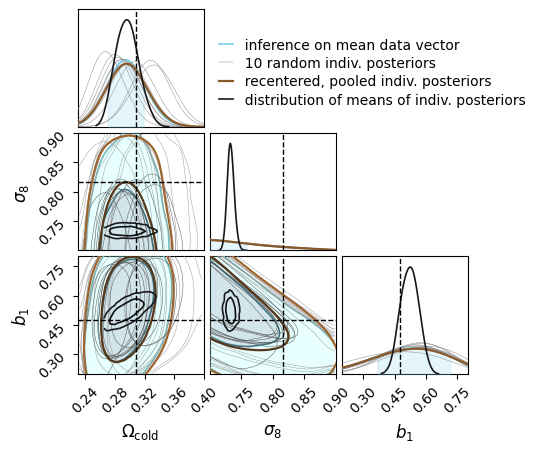

In [5]:
# A1: Pgg
plot_a1_variant(
    statistics_row=["pk"],
    tag_masks_row="",
    color_mean=COLORS_FID[0],
    save_name="figA1_pk",
)


$P_\mathrm{gg}$ + $P_\mathrm{gm}$: fn_samples (indiv) = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/figA1_recentered_pooled_pk_pgm_k500.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500)
overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figure

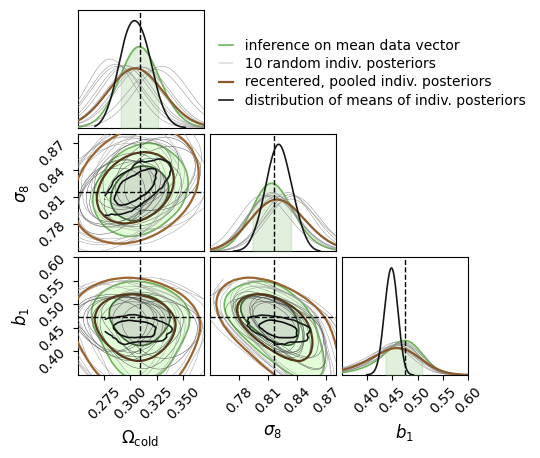

In [6]:
# A1: Pgg+Pgm
plot_a1_variant(
    statistics_row=["pk", "pgm"],
    tag_masks_row="_kpgm0.25",
    color_mean=COLORS_FID[1],
    save_name="figA1_pk_pgm",
)


$P_\mathrm{gg}$ + $B_\mathrm{ggg}$: fn_samples (indiv) = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/figA1_recentered_pooled_pk_bispec_k500.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500)
overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimock

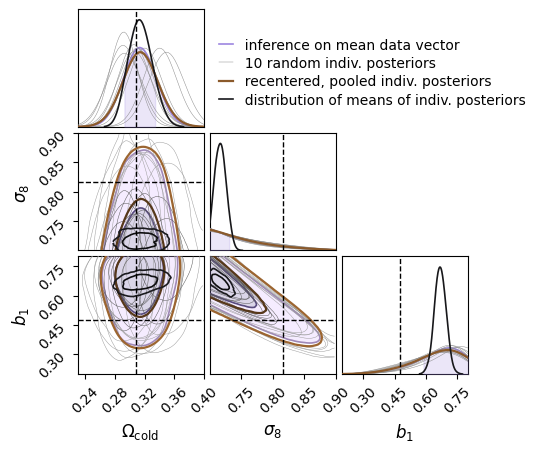

In [7]:
# A1: Pgg+bispec
plot_a1_variant(
    statistics_row=["pk", "bispec"],
    tag_masks_row="_kb0.25",
    color_mean=COLORS_FID[2],
    save_name="figA1_pk_bispec",
)


$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ + $P_\mathrm{gm}$: fn_samples (indiv) = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/figA1b_recentered_pooled_pk_bispec_pgm_k500.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500)
overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n

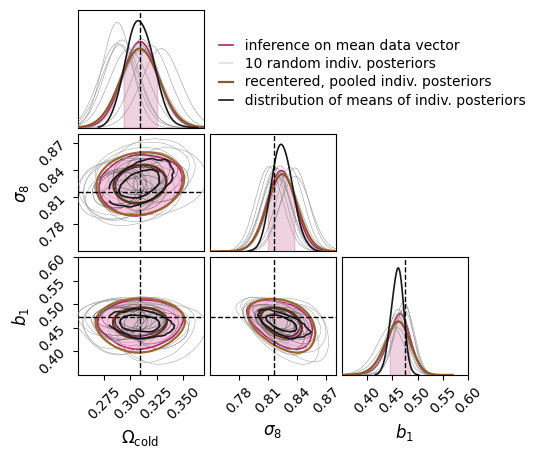

In [8]:
# A1: Pgg+bispec+Pgm
plot_a1_variant(
    statistics_row=["pk", "bispec", "pgm"],
    tag_masks_row="_kb0.25_kpgm0.25",
    color_mean=COLORS_FID[3],
    save_name="figA1_pk_bispec_pgm",
)


### A1: $P_\mathrm{gm}$-only and $B_\mathrm{ggg}$-only

Single-statistic inference on the fixed-cosmo shame test set ($n_\mathrm{obs}=1000$): CV-mean posterior vs thin grey individual realizations, brown recentered-pooled uncertainty, and black distribution of posterior means.


$P_\mathrm{gm}$: fn_samples (indiv) = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/figA1_recentered_pooled_pgm_k500.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500)
overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/figA

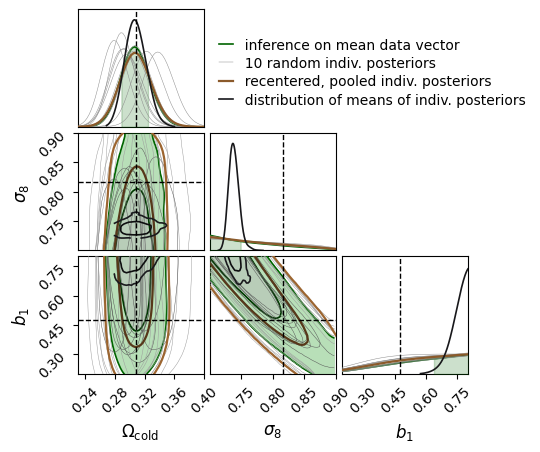

In [9]:
# A1: Pgm-only
plot_a1_variant(
    statistics_row=["pgm"],
    tag_masks_row="_kpgm0.25",
    color_mean=COLOR_PGM_SOLO,
    save_name="figA1_pgm",
    extents=EXTENTS_A_WIDE
)


$B_\mathrm{ggg}$: fn_samples (indiv) = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy
Loaded cache: /home/kstoreyf/muchisimocks/figures/paper_figures_cache/figA1_recentered_pooled_bispec_k500.pkl
contouring posterior means for 1000 realizations; pooled recentered samples: 500000 (n_obs=1000 × k=500)
overlaying 10 random indiv. posteriors, obs_idx=[ 85 767  88 649 436 430 695  94 201 855]
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_varia

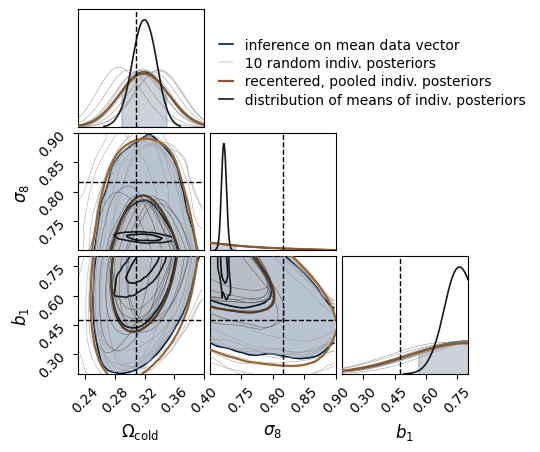

In [10]:
# A1: Bispec-only
plot_a1_variant(
    statistics_row=["bispec"],
    tag_masks_row="_kb0.25",
    color_mean=COLOR_BISPEC_SOLO,
    save_name="figA1_bispec",
    extents=EXTENTS_A_WIDE
)


## Cosmic variance & SHAMe contours ($\sigma_8 b_1$)


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2

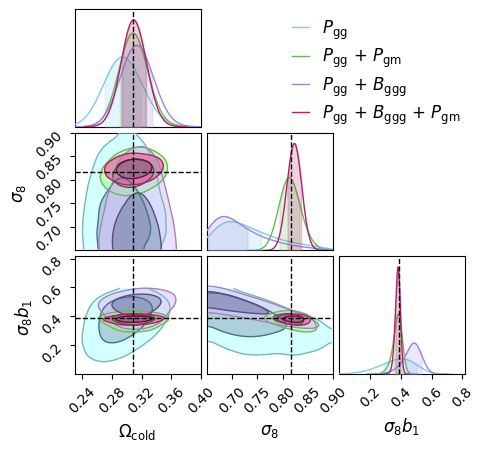

In [11]:
# Cosmic variance (fixed-cosmo mean) in (Ωc, σ8, σ8 b1)
tags_inf, labels, colors, tags_test, keep, _, theta_show_cv, _ = setup_fixed_mean_test()

plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep,
    theta_show=theta_show_sigma8xb1(theta_show_cv),
    extents=extents_sigma8xb1(theta_show_cv),
    param_names=list(param_names_key_rp),
    unreparameterize=False,
    save_name="fig3_cosmic_variance_contours_sigma8xb1",
)


SHAMe OOD contours: $\bar{n}=1.1\times10^{-4}$ → fig6_shame_contours_sigma8xb1_nbar0.00011
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_tes

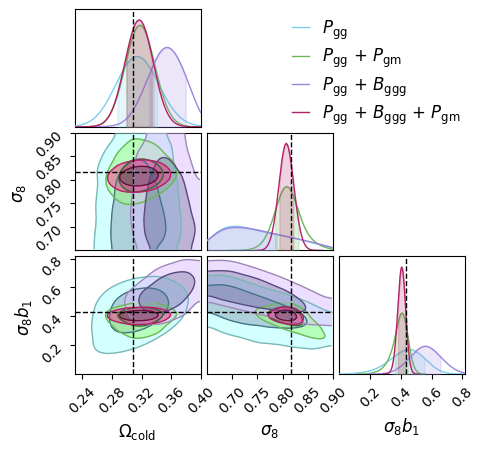

SHAMe OOD contours: $\bar{n}=2.2\times10^{-4}$ → fig6_shame_contours_sigma8xb1
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_b

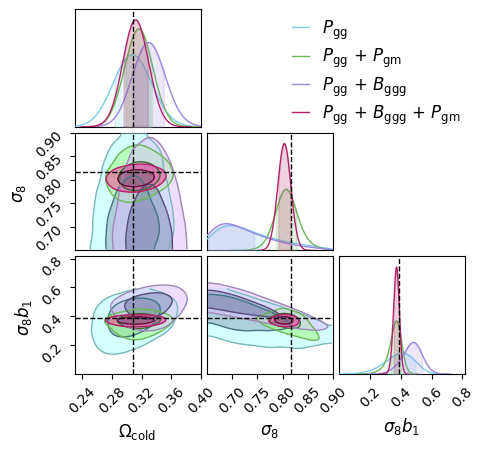

SHAMe OOD contours: $\bar{n}=5.4\times10^{-4}$ → fig6_shame_contours_sigma8xb1_nbar0.00054
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00054_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00054_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00054_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_tes

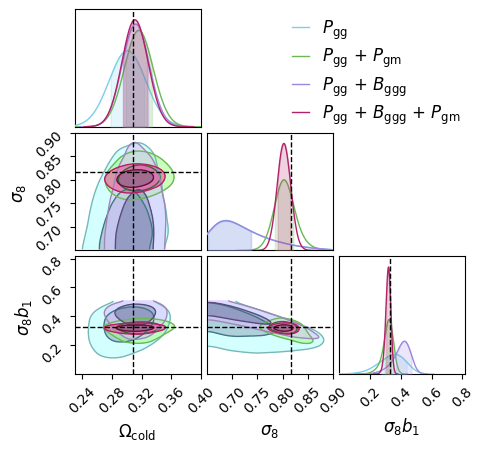

In [12]:
# SHAMe OOD in (Ωc, σ8, σ8 b1) — all three number densities
for tag_mock in NBAR_TAGS_SHAME:
    tags_inf, labels, colors, tags_test, keep, _, theta_show_shame = setup_shame_test(
        tag_mock=tag_mock,
    )
    nbar_slug = tag_mock.replace("_nbar", "nbar")
    save_name = (
        "fig6_shame_contours_sigma8xb1"
        if tag_mock == TAG_MOCK_SHAME
        else f"fig6_shame_contours_sigma8xb1_{nbar_slug}"
    )
    print(f"SHAMe OOD contours: {NBAR_LABELS_SHAME[tag_mock]} → {save_name}")
    plot_fiducial_contours(
        tags_inf, labels, colors, tags_test, keep,
        theta_show=theta_show_sigma8xb1(theta_show_shame),
        extents=extents_sigma8xb1(theta_show_shame),
        param_names=list(param_names_key_rp),
        unreparameterize=False,
        save_name=save_name,
    )


# kmax checks


## kmax pgm & bispec, with $k_{\mathrm{max}}^{P_{gg}}=0.35$


### shame — top model


MISSING FoB3 point | panel=bispec sweep (PGM kmax=0.25 fixed, shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar0.00011 | k_max=0.27 | tried: '_kp0.35_kb0.27': missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kp0.35_kb0.27_nbar0.00011_pred.npy
MISSING FoB3 point | panel=bispec sweep (PGM kmax=0.25 fixed, shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar0.00011 | k_max=0.32 | tried: '_kp0.35_kb0.32': missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.32_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kp0.35_kb0.32_nbar0.00011_pred.npy
MISSING FoB3 point | panel=bispec sweep (PGM kmax=0.25 fixed, shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar

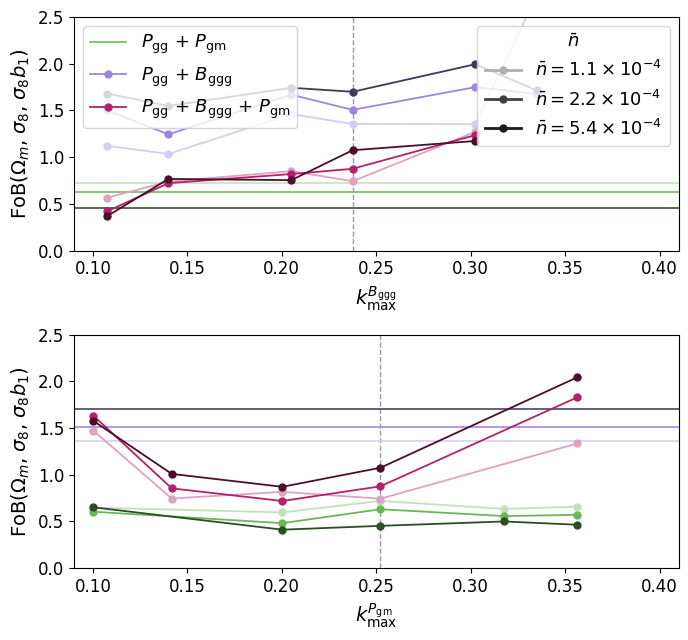

MISSING FoM3 point | panel=bispec sweep (PGM kmax=0.25 fixed, shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar0.00011 | k_max=0.27 | tried: '_kp0.35_kb0.27': missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kp0.35_kb0.27_nbar0.00011_pred.npy
MISSING FoM3 point | panel=bispec sweep (PGM kmax=0.25 fixed, shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar0.00011 | k_max=0.32 | tried: '_kp0.35_kb0.32': missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.32_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kp0.35_kb0.32_nbar0.00011_pred.npy
MISSING FoM3 point | panel=bispec sweep (PGM kmax=0.25 fixed, shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar

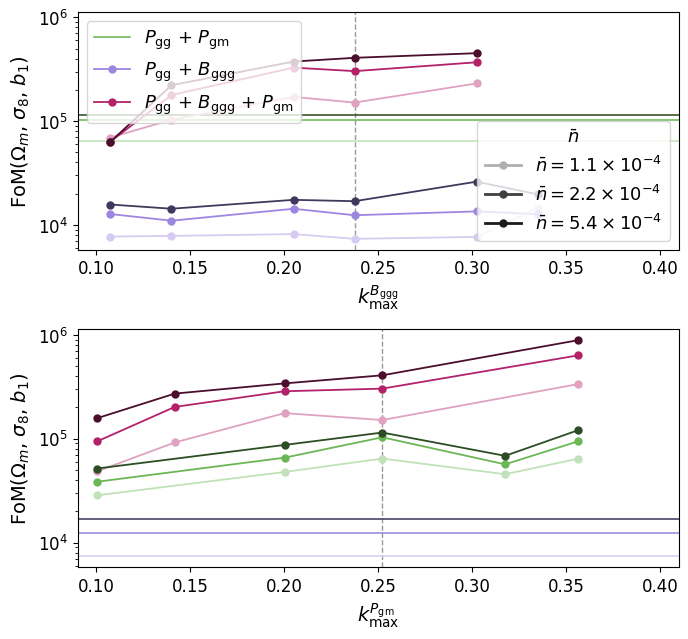

In [7]:
plot_scale_fob3_top(
    test_mode="shame",
    save_name="fig9_scale_dependence_fob3_nbars",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_fom3_top(
    test_mode="shame",
    save_name="fig8_scale_dependence_fom3_nbars",
)


### shame — k=3 ensemble


MISSING FoB3 point | panel=bispec sweep ensemble (shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar0.00011 | k_max=0.1 | tried: '_kp0.35_kb0.1': nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_shame_pk_bispec_kp0.35_kb0.1_nbar0.00011_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_shame_pk_bispec_kp0.35_kb0.1_nbar0.00011_pred.npy
MISSING FoB3 point | panel=bispec sweep ensemble (shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar0.00011 | k_max=0.15 | tried: '_kp0.35_kb0.15': nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.15_p5_n10000_biasnoisenest_p9_n320000_noise_un

MISSING FoB3 point | panel=bispec sweep ensemble (shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ + $P_\mathrm{gm}$ | nbar=_nbar0.00011 | k_max=0.1 | tried: '_kp0.35_kb0.1_kpgm0.25': nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.1_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_shame_pk_bispec_pgm_kp0.35_kb0.1_kpgm0.25_nbar0.00011_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.35_kb0.1_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_shame_pk_bispec_pgm_kp0.35_kb0.1_kpgm0.25_nbar0.00011_pred.npy
MISSING FoB3 point | panel=bispec sweep ensemble (shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ + $P_\mathrm{gm}$ | nbar=_nbar0.00011 | k_max=0.15 | tried: '_kp0.35_kb0.15_kpgm0.25': nbest1: missing /scratch/kstoreyf/muchisimock

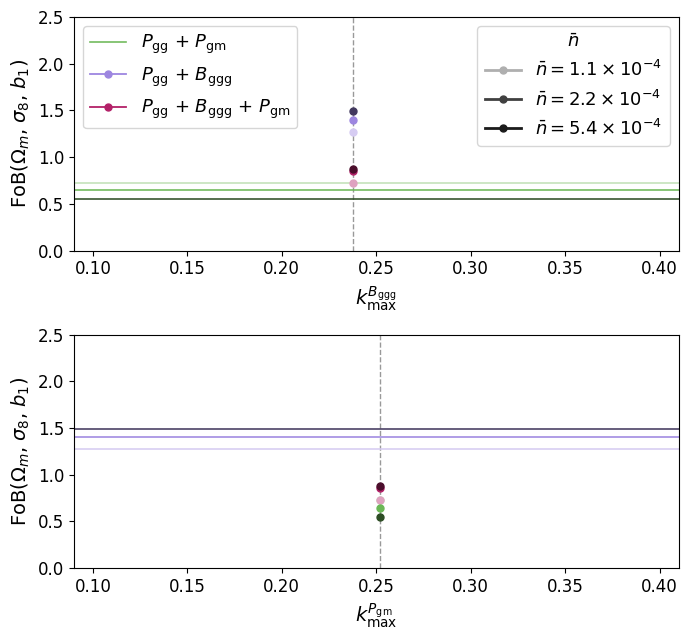

MISSING FoM3 point | panel=bispec sweep ensemble FoM (shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar0.00011 | k_max=0.1 | tried: '_kp0.35_kb0.1': nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_shame_pk_bispec_kp0.35_kb0.1_nbar0.00011_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_shame_pk_bispec_kp0.35_kb0.1_nbar0.00011_pred.npy
MISSING FoM3 point | panel=bispec sweep ensemble FoM (shame) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=_nbar0.00011 | k_max=0.15 | tried: '_kp0.35_kb0.15': nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.15_p5_n10000_biasnoisenest_p9_n320000_

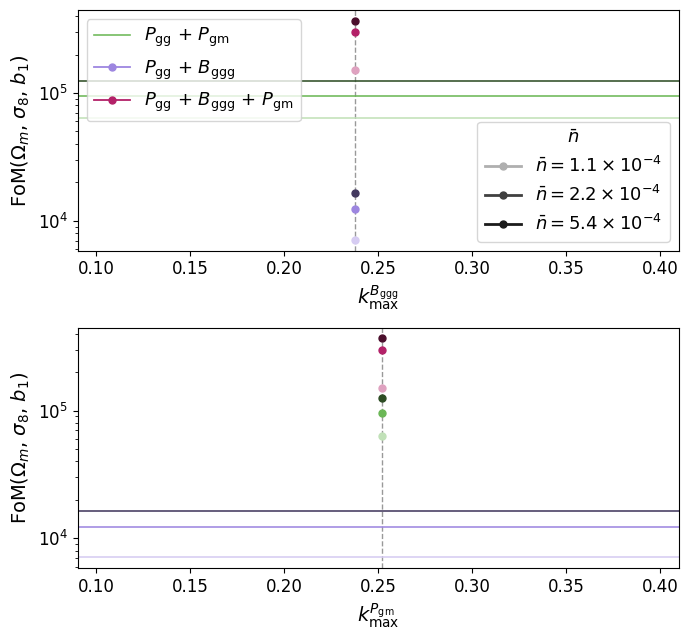

In [36]:
# SHAMe OOD — per-stat k_max sweeps (ensemble)
plot_scale_fob3_ensemble(
    test_mode="shame",
    save_name="fig16_scale_dependence_fob3_nbars_ensemble_shame",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_fom3_ensemble(
    test_mode="shame",
    save_name="fig20_scale_dependence_fom3_nbars_ensemble_shame",
)


### cvmean — top model


MISSING FoB3 point | panel=bispec sweep (PGM kmax=0.25 fixed, cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.27 | tried: '_kp0.35_kb0.27': missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
MISSING FoB3 point | panel=bispec sweep (PGM kmax=0.25 fixed, cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.32 | tried: '_kp0.35_kb0.32': missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.32_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.32_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


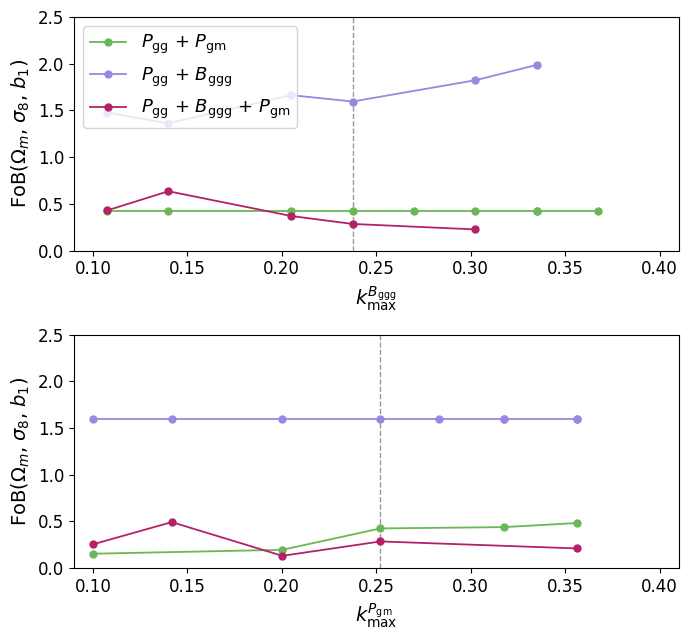

MISSING FoM3 point | panel=bispec sweep (PGM kmax=0.25 fixed, cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.27 | tried: '_kp0.35_kb0.27': missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
MISSING FoM3 point | panel=bispec sweep (PGM kmax=0.25 fixed, cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.32 | tried: '_kp0.35_kb0.32': missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.32_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.32_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


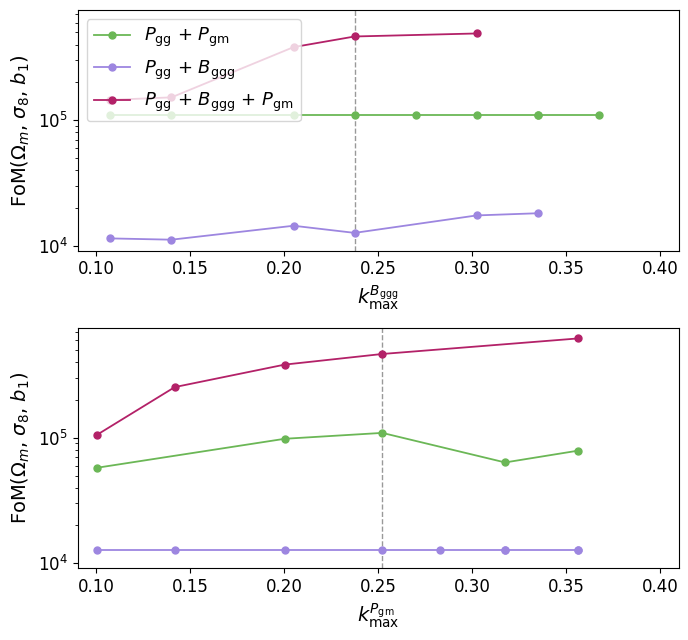

In [37]:
plot_scale_fob3_top(
    test_mode="cvmean",
    save_name="fig9b_scale_dependence_fob3_cvmean",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_fom3_top(
    test_mode="cvmean",
    save_name="fig8b_scale_dependence_fom3_cvmean",
)


### cvmean — k=3 ensemble


MISSING FoB3 point | panel=bispec sweep ensemble (cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.1 | tried: '_kp0.35_kb0.1': nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
MISSING FoB3 point | panel=bispec sweep ensemble (cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.15 | tried: '_kp0.35_kb0.15': nbest1: missing /scratch/ks

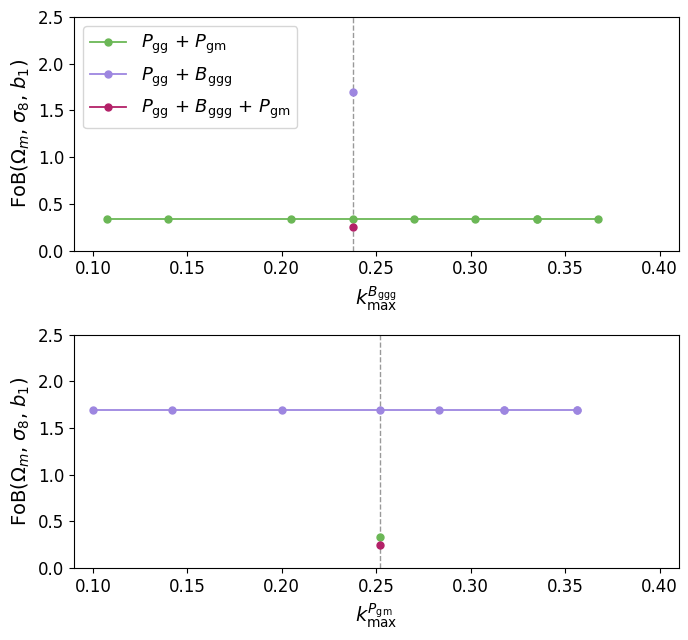

MISSING FoM3 point | panel=bispec sweep ensemble FoM (cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.1 | tried: '_kp0.35_kb0.1': nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.35_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_muchisimocks_pk_bispec_kp0.35_kb0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
MISSING FoM3 point | panel=bispec sweep ensemble FoM (cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.15 | tried: '_kp0.35_kb0.15': nbest1: missing /sc

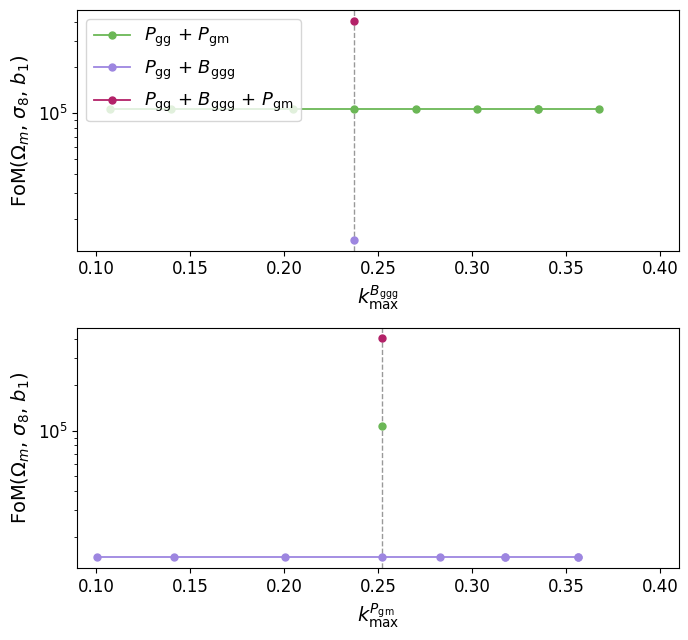

In [38]:
# CV-mean — per-stat k_max sweeps (ensemble)
plot_scale_fob3_ensemble(
    test_mode="cvmean",
    save_name="fig17_scale_dependence_fob3_nbars_ensemble_cvmean",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_fom3_ensemble(
    test_mode="cvmean",
    save_name="fig21_scale_dependence_fom3_nbars_ensemble_cvmean",
)


## kmax joint


### shame — top model


MISSING FoB3 point | panel=overall kmax (shame) | stats=$P_\mathrm{gg}$ | nbar=_nbar0.00011 | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_kp0.27_nbar0.00011_pred.npy
MISSING FoB3 point | panel=overall kmax (shame) | stats=$P_\mathrm{gg}$ | nbar=_nbar0.00022 | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_kp0.27_nbar0.00022_pred.npy
MISSING FoB3 point | panel=overall kmax (shame) | stats=$P_\mathrm{gg}$ | nbar=_nbar0.00054 | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-r

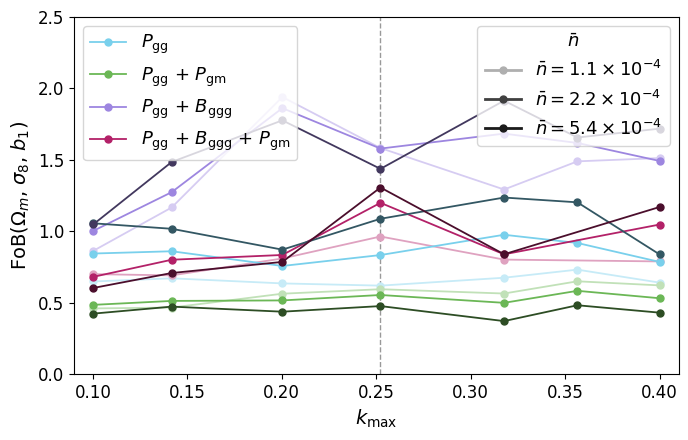

MISSING FoM3 point | panel=overall kmax (omega_cold, shame) | stats=$P_\mathrm{gg}$ | nbar=_nbar0.00011 | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_kp0.27_nbar0.00011_pred.npy
MISSING FoM3 point | panel=overall kmax (omega_cold, shame) | stats=$P_\mathrm{gg}$ | nbar=_nbar0.00022 | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_kp0.27_nbar0.00022_pred.npy
MISSING FoM3 point | panel=overall kmax (omega_cold, shame) | stats=$P_\mathrm{gg}$ | nbar=_nbar0.00054 | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_

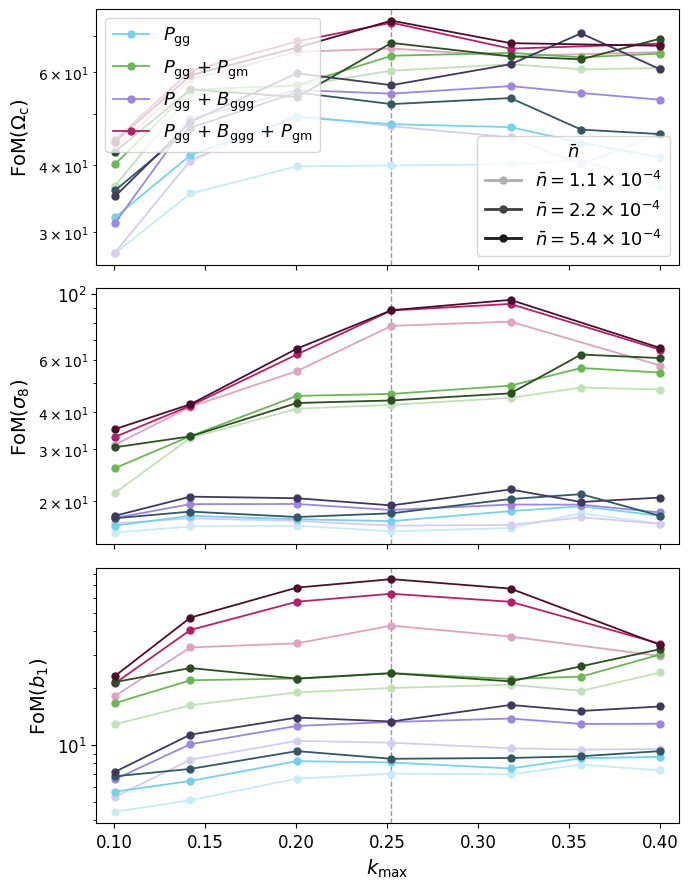

In [39]:
plot_scale_overall_kmax_fob3_shame_nbars(
    save_name="fig10_scale_dependence_overall_kmax_fob3_nbars",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_overall_kmax_fom3_shame_nbars(
    save_name="fig11_scale_dependence_overall_kmax_fom_marg_nbars",
)


### shame — k=3 ensemble


MISSING FoB3 | overall kmax ensemble | stats=$P_\mathrm{gg}$ | _nbar0.00011 | k=0.27 | nbest0: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_kp0.27_nbar0.00011_pred.npy; nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_shame_pk_kp0.27_nbar0.00011_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_shame_pk_kp0.27_nbar0.00011_pred.npy
MISSING FoB3 | overall kmax ensemble | stats=$P_\mathrm{gg}$ | _nbar0.00022 | k=0.27 | nbest0: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisen

MISSING FoB3 | overall kmax ensemble | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | _nbar0.00011 | k=0.27 | nbest0: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.27_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kp0.27_kb0.25_nbar0.00011_pred.npy; nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.27_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_shame_pk_bispec_kp0.27_kb0.25_nbar0.00011_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kp0.27_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_shame_pk_bispec_kp0.27_kb0.25_nbar0.00011_pred.npy
MISSING FoB3 | overall kmax ensemble | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | _nbar0.00022 | k

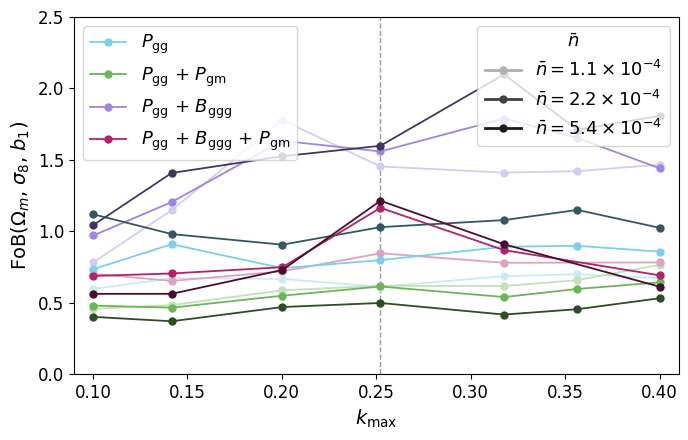

MISSING FoM | overall kmax ensemble | param=omega_cold | stats=$P_\mathrm{gg}$ | _nbar0.00011 | k=0.27 | nbest0: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_kp0.27_nbar0.00011_pred.npy; nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_shame_pk_kp0.27_nbar0.00011_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_shame_pk_kp0.27_nbar0.00011_pred.npy
MISSING FoM | overall kmax ensemble | param=omega_cold | stats=$P_\mathrm{gg}$ | _nbar0.00022 | k=0.27 | nbest0: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisi

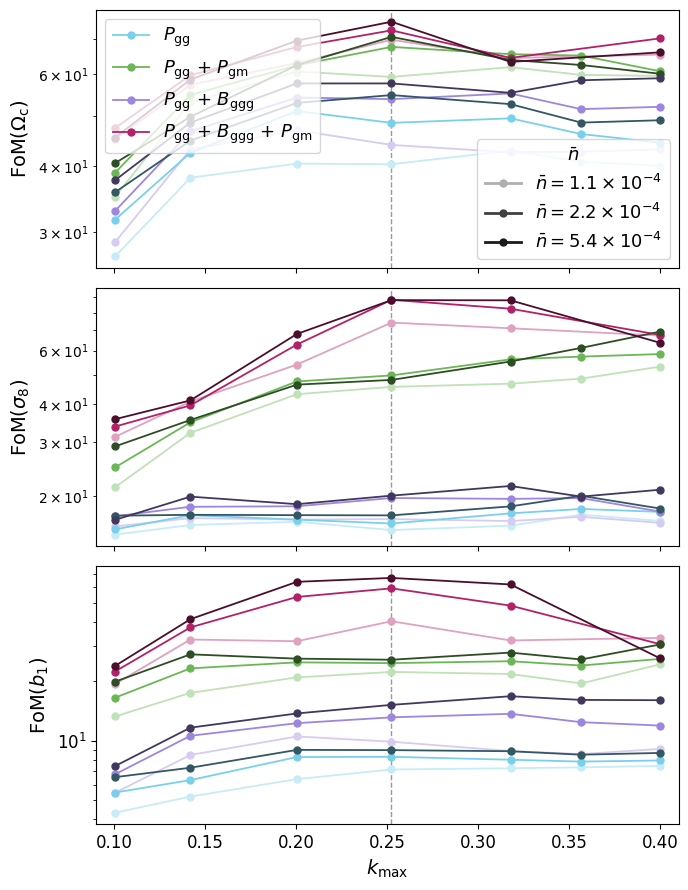

In [40]:
# SHAMe OOD — overall joint k_max (ensemble)
plot_scale_overall_kmax_fob3_ensemble(
    test_mode="shame",
    save_name="fig18_scale_dependence_overall_kmax_fob3_nbars_ensemble_shame",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_overall_kmax_fom3_ensemble(
    test_mode="shame",
    save_name="fig22_scale_dependence_overall_kmax_fom_marg_nbars_ensemble_shame",
)


### cvmean — top model


MISSING FoB3 point | panel=overall kmax (cvmean) | stats=$P_\mathrm{gg}$ | nbar=cvmean | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.27_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
MISSING FoB3 point | panel=overall kmax (cvmean) | stats=$P_\mathrm{gg}$ + $P_\mathrm{gm}$ | nbar=cvmean | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.27_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.27_kpgm0.25_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
MISSING FoB3 point | panel=overall kmax (cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi

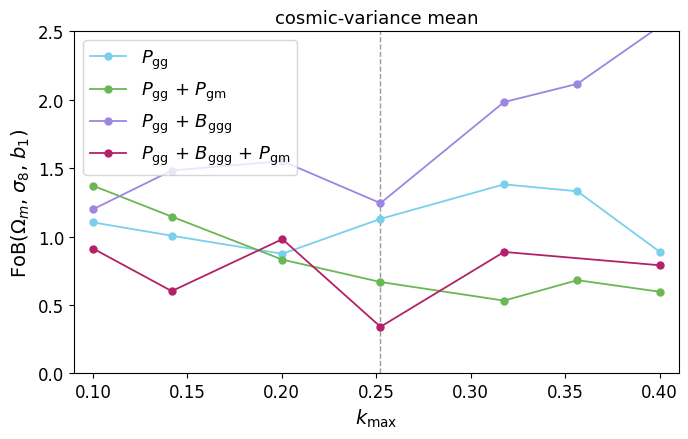

MISSING FoM3 point | panel=overall kmax (omega_cold, cvmean) | stats=$P_\mathrm{gg}$ | nbar=cvmean | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.27_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
MISSING FoM3 point | panel=overall kmax (omega_cold, cvmean) | stats=$P_\mathrm{gg}$ + $P_\mathrm{gm}$ | nbar=cvmean | k_max=0.27 | tried: missing samples file: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kp0.27_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kp0.27_kpgm0.25_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
MISSING FoM3 point | panel=overall kmax (omega_cold, cvmean) | stats=$P_\mathrm{gg}$ + $B_\mathrm{ggg}$ | nbar=cvmean | k_max=0.27 | tried: missing samples file: /scratch/kstor

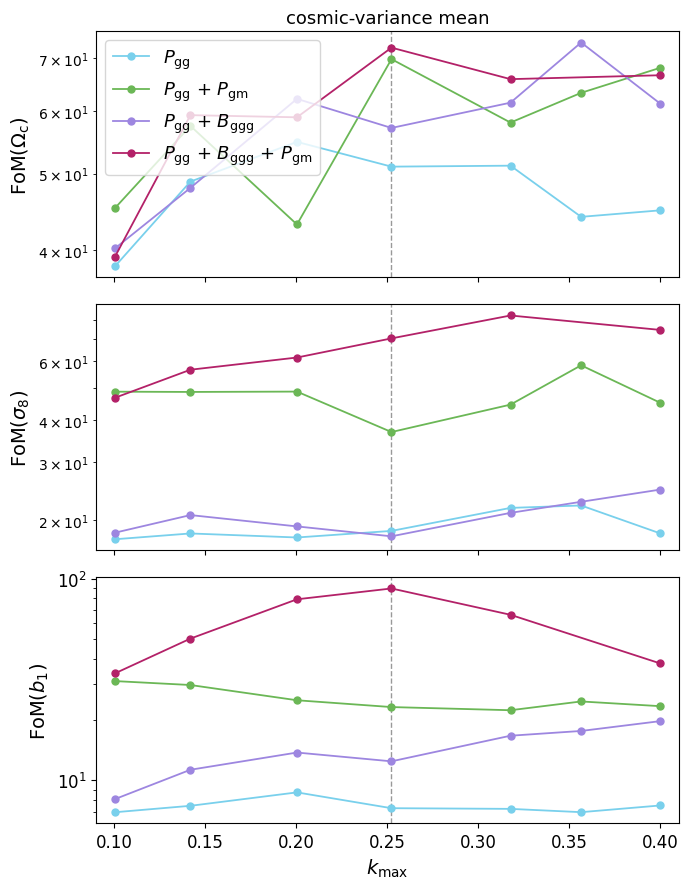

In [41]:
plot_scale_overall_kmax_fob3(
    test_mode="cvmean",
    save_name="fig14_scale_dependence_overall_kmax_fob3_cvmean",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_overall_kmax_fom3(
    test_mode="cvmean",
    save_name="fig15_scale_dependence_overall_kmax_fom_marg_cvmean",
)


### cvmean — k=3 ensemble


MISSING FoB3 | overall kmax ensemble | stats=$P_\mathrm{gg}$ | cvmean | k=0.27 | nbest0: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy; nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_kp0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_muchisimocks_pk_kp0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
MISSIN

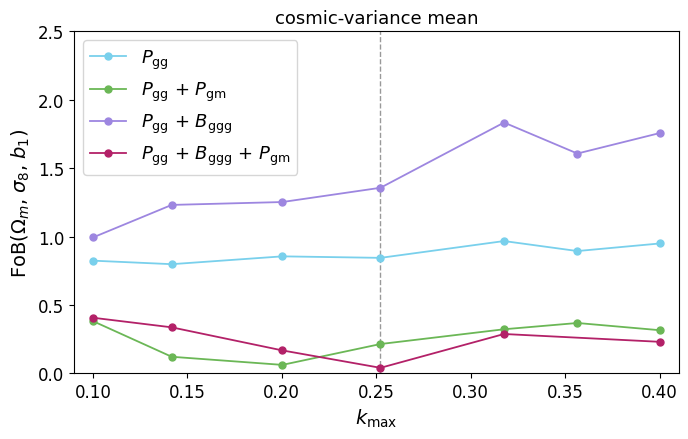

MISSING FoM | overall kmax ensemble | param=omega_cold | stats=$P_\mathrm{gg}$ | cvmean | k=0.27 | nbest0: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_kp0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy; nbest1: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest1/samples_test_muchisimocks_pk_kp0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy; nbest2: missing /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_kp0.27_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest2/samples_test_muchisimocks_pk_kp0.27_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_me

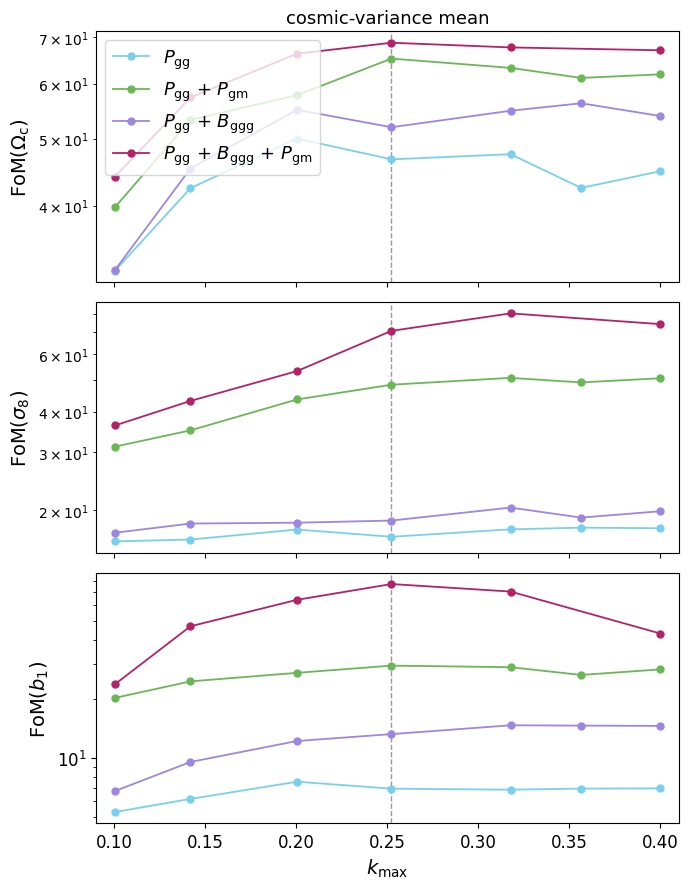

In [42]:
# CV-mean — overall joint k_max (ensemble)
plot_scale_overall_kmax_fob3_ensemble(
    test_mode="cvmean",
    save_name="fig19_scale_dependence_overall_kmax_fob3_ensemble_cvmean",
    param_names_fob=PARAM_NAMES_FOB,
    fob_keys=FOB_KEYS,
    ylabel=FOB3_YLABEL,
)
plot_scale_overall_kmax_fom3_ensemble(
    test_mode="cvmean",
    save_name="fig23_scale_dependence_overall_kmax_fom_marg_ensemble_cvmean",
)


## kmax contours


### shame, kmax joint


MISSING overall-k contour | shame | k=0.27 | /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.27_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kp0.27_kb0.25_kpgm0.25_nbar0.00022_pred.npy
MISSING overall-k contour | shame | k=0.37 | /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.37_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kp0.37_kb0.25_kpgm0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.1_kb0.1_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kp0.1_kb0.1_kpgm0.1_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pg

/tmp/ipykernel_1447983/1930312618.py:1209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig12_overall_kmax_contours_full_combo_nbar0.00022.png


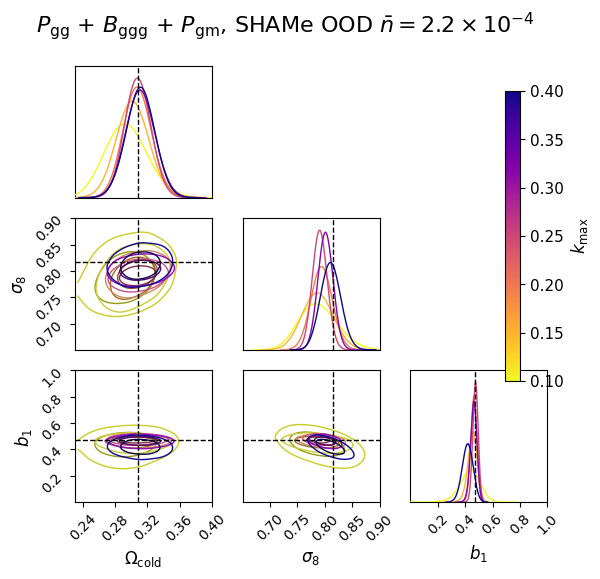

Skipped 2 k points (missing samples)


In [43]:
plot_overall_kmax_contours_full_combo(
    tag_mock=TAG_MOCK_SHAME,
    save_name="fig12_overall_kmax_contours_full_combo_nbar0.00022",
)


### cv, kmax joint


MISSING overall-k contour | cvmean | k=0.27 | /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.27_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.27_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
MISSING overall-k contour | cvmean | k=0.37 | /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.37_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.37_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kp0.1_kb0.1_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kp0.1_kb0.1_kpgm0.1_shame_p0_n1000_biasshame_p0_n1_mean_pred.np

/tmp/ipykernel_1447983/1930312618.py:1209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-19_figure_variants/fig13_overall_kmax_contours_full_combo_cvmean.png


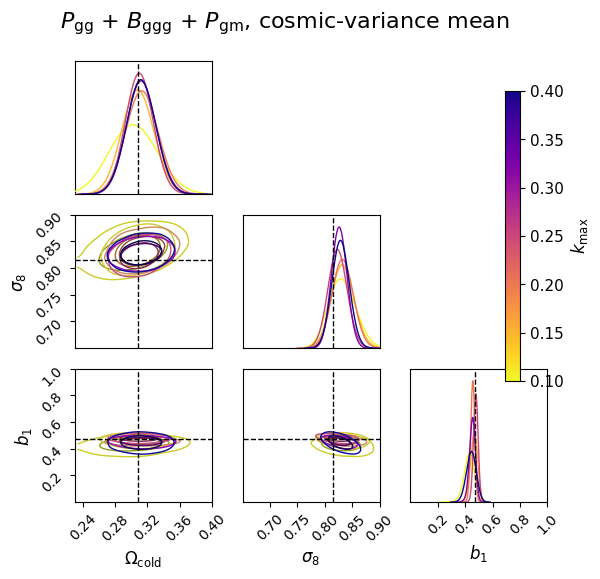

Skipped 2 k points (missing samples)


In [44]:
plot_overall_kmax_contours_full_combo(
    test_mode="cvmean",
    save_name="fig13_overall_kmax_contours_full_combo_cvmean",
)
